# Setup

In [3]:
import pandas as pd
import talib
import numpy as np
import os
import shutil
import warnings

warnings.filterwarnings('ignore')



WINDOWS = {
    'long': 60, # 30 minutes
    'medium':20,
    'short': 5   # 10 minutes
}
# PATH = os.path.join("..", "data","combined.csv")
PATH = os.path.join("..", "cli", "data","BTCUSDT_1m.csv")


def create_images_directory(directory_name="images"):
    if os.path.exists(directory_name):
        shutil.rmtree(directory_name)  
    os.makedirs(directory_name) 

create_images_directory()


def get_data(file_loc, n=None):
    "Used to read main.csv etc"
    if n is None:
        data = pd.read_csv(file_loc)
    else:
        data = pd.read_csv(file_loc, nrows=n)

    data.columns = data.columns.str.lower()

    data['datetime'] = pd.to_datetime(data['datetime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    
    data.dropna(inplace=True, axis=0)

    data.columns = data.columns.str.lower()

    data = data.sort_values(by=["datetime"])

    if 'volume' in data.columns:
        data.drop('volume', axis=1, inplace=True)

    return data
   



In [13]:
data = get_data(PATH)

# Data Quality Check
total_rows = len(data)
missing_values = data.isnull().sum().sum()

data.fillna(data.mean(), inplace=True)

# Data Quality Check after fixing
fixed_missing_values = data.isnull().sum().sum()

# Create a DataFrame for the data quality check results
data_quality = {
    "Description": ["Total Rows", "Missing Values", "Fixed Missing Values"],
    "Count": [total_rows, missing_values, fixed_missing_values]
}

data_quality_df = pd.DataFrame(data_quality)

# Display the quality check results
print("Data Quality Check Results:\n", data_quality_df.to_string(index=False))

# Output the fixed data
print("\nSample of Fixed Data:\n", data.head().to_string())

Data Quality Check Results:
          Description  Count
          Total Rows 279213
      Missing Values      0
Fixed Missing Values      0

Sample of Fixed Data:
              datetime      open      high       low     close
0 2023-01-01 00:00:00  16541.77  16544.76  16538.45  16543.67
1 2023-01-01 00:01:00  16543.04  16544.41  16538.48  16539.31
2 2023-01-01 00:02:00  16539.31  16541.17  16534.52  16536.43
3 2023-01-01 00:03:00  16536.43  16537.28  16531.00  16533.65
4 2023-01-01 00:04:00  16534.12  16536.08  16527.51  16535.38


# Scope and TA demo

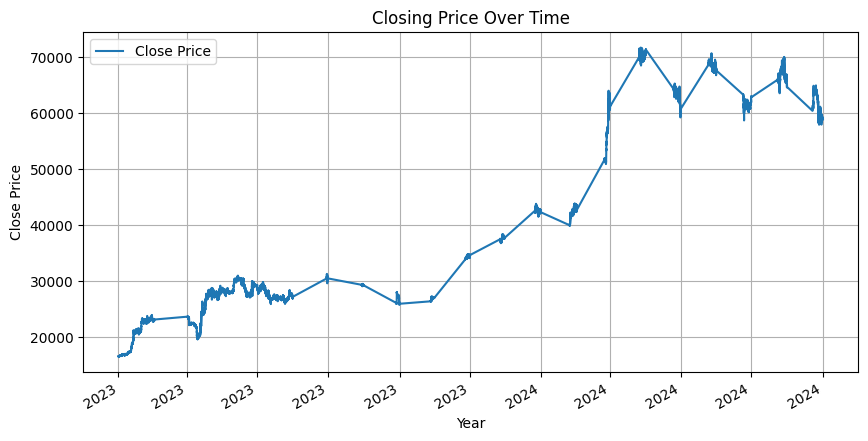

In [14]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig_path = os.path.join("images", "scope.png")
plt.figure(figsize=(10, 5))
plt.plot(data['datetime'], data['close'], label='Close Price')
plt.title('Closing Price Over Time')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

# Format the x-axis to display years
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# Rotate date labels for better readability
plt.gcf().autofmt_xdate()

plt.savefig(fig_path)
plt.show()


In [6]:
import plotly.graph_objects as go
import plotly.io as pio
import os
import talib

# Initialize Plotly to display in the browser
pio.renderers.default = 'browser'

# Path to save the image
fig_path = os.path.join("images", "example_tech_ind.png")

def plot_features(data):
    # Check if 'datetime' is already in the index, if not, set it
    if 'datetime' not in data.index.names:
        data.set_index('datetime', inplace=True)
    
    # Calculate moving averages
    data['SMA_10'] = talib.SMA(data['close'], timeperiod=10)
    data['SMA_30'] = talib.SMA(data['close'], timeperiod=30)

    # Calculate Bollinger Bands
    data['upperband_10'], data['middleband_10'], data['lowerband_10'] = talib.BBANDS(data['close'], timeperiod=10)
    data['upperband_30'], data['middleband_30'], data['lowerband_30'] = talib.BBANDS(data['close'], timeperiod=30)

    # Subset of 100 continuous points
    subset_data = data.iloc[1:101]

    # Get the highest (most recent) datetime
    latest_datetime = subset_data.index[28]

    # Create a figure
    fig = go.Figure()

    # Add OHLC data
    fig.add_trace(go.Candlestick(x=subset_data.index,
                                 open=subset_data['open'],
                                 high=subset_data['high'],
                                 low=subset_data['low'],
                                 close=subset_data['close'],
                                 name='OHLC'))

    # Add moving averages
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['SMA_10'], mode='lines', name='10-min SMA', line=dict(color='green')))
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['SMA_30'], mode='lines', name='30-min SMA', line=dict(color='orange')))

    # Add Bollinger Bands
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['upperband_10'], mode='lines', name='10-min Upper BB', line=dict(color='cyan')))
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['lowerband_10'], mode='lines', name='10-min Lower BB', line=dict(color='cyan')))
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['upperband_30'], mode='lines', name='30-min Upper BB', line=dict(color='pink')))
    fig.add_trace(go.Scatter(x=subset_data.index, y=subset_data['lowerband_30'], mode='lines', name='30-min Lower BB', line=dict(color='pink')))

    # Add a vertical dashed line at the highest datetime index
    fig.add_shape(type='line',
                  x0=latest_datetime, y0=0, x1=latest_datetime, y1=1,
                  xref='x', yref='paper',
                  line=dict(color='gray', width=2, dash='dash'))

    # Update layout with white background
    fig.update_layout(
        template='plotly_white',
        title='OHLC Candles with SMA and Bollinger Bands',
        xaxis_title='DateTime',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        plot_bgcolor='white',  # Set plot background to white
        paper_bgcolor='white'  # Set paper background to white
    )

    # Create the images directory if it doesn't exist
    os.makedirs('images', exist_ok=True)

    # Save the figure as a PNG file
    pio.write_image(fig, fig_path, engine='kaleido')

    # Show the figure
    fig.show()

# Assuming `data` is your dataset containing 'datetime', 'open', 'high', 'low', 'close' columns
plot_features(data.copy())


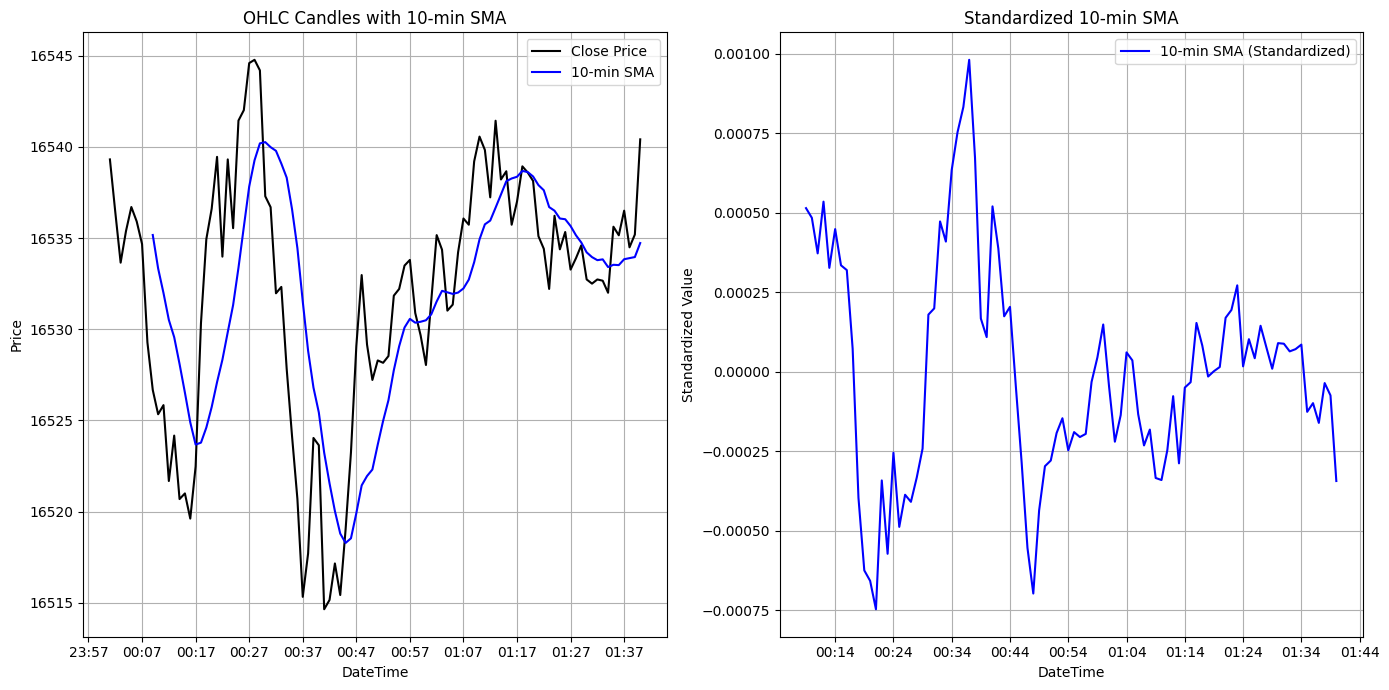

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import talib
import os

def plot_moving_average(data):
    # Calculate the 10-minute simple moving average
    data['SMA_10'] = talib.SMA(data['close'], timeperiod=10)

    # Standardize the moving average with respect to the close price
    data['SMA_10_std'] = (data['SMA_10'] - data['close']) / data['close']

    # Subset of 100 continuous points
    subset_data = data.iloc[1:101]

    # Create subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

    # Format the datetime x-axis
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

    # Plot 1: OHLC data with SMA on the left
    axes[0].plot(subset_data['datetime'], subset_data['close'], label='Close Price', color='black')
    axes[0].plot(subset_data['datetime'], subset_data['SMA_10'], label='10-min SMA', color='blue')
    axes[0].set_title('OHLC Candles with 10-min SMA')
    axes[0].set_xlabel('DateTime')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2: Standardized SMA on the right
    axes[1].plot(subset_data['datetime'], subset_data['SMA_10_std'], label='10-min SMA (Standardized)', color='blue')
    axes[1].set_title('Standardized 10-min SMA')
    axes[1].set_xlabel('DateTime')
    axes[1].set_ylabel('Standardized Value')
    axes[1].legend()
    axes[1].grid(True)

    # Adjust layout
    plt.tight_layout()

    # Create 'images' directory if it doesn't exist
    os.makedirs('images', exist_ok=True)

    # Save the figure to the specified path
    fig_path = os.path.join('images', 'stdize_tech_example.png')
    plt.savefig(fig_path)

    # Show the plot
    plt.show()

# Call the function with the data
plot_moving_average(data.copy())


- Example of Linearity of PCA

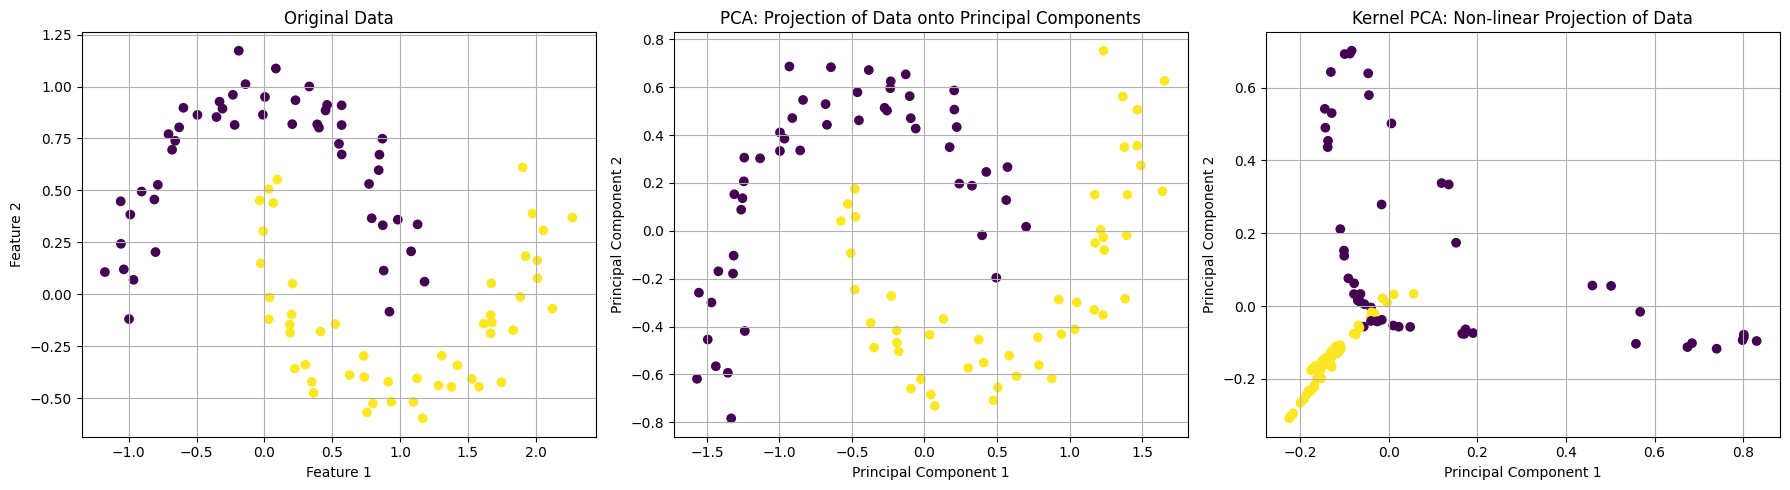

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_moons
import os

# Ensure the images directory exists
image_dir = "images"

# Generate sample data
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply Kernel PCA
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X)

# Plot Original Data
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

# Plot PCA results
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA: Projection of Data onto Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Plot Kernel PCA results
plt.subplot(1, 3, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis')
plt.title('Kernel PCA: Non-linear Projection of Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'nonlinearpca_eg.png'))

# Show the plot
plt.show()


# Feature extraction

In [9]:
def resample_candlestick_data(df, frequency):
    df.set_index('datetime', inplace=True)
    
    resampled_df = df.resample(frequency).agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last'
    }).dropna()

    resampled_df.reset_index(inplace=True)

    return resampled_df
data_ori = data.copy()
data = resample_candlestick_data(data, '1min')
print("\nResampled Data (15 Minutes):\n", data.head().to_string())
print(data.shape)



Resampled Data (15 Minutes):
              datetime      open      high       low     close
0 2023-01-01 00:00:00  16541.77  16544.76  16538.45  16543.67
1 2023-01-01 00:01:00  16543.04  16544.41  16538.48  16539.31
2 2023-01-01 00:02:00  16539.31  16541.17  16534.52  16536.43
3 2023-01-01 00:03:00  16536.43  16537.28  16531.00  16533.65
4 2023-01-01 00:04:00  16534.12  16536.08  16527.51  16535.38
(279213, 5)


In [10]:
import pandas as pd
import numpy as np

def extract_features(data):
    features = {}
    for window_name, window_size in WINDOWS.items():
        ema = talib.EMA(data['close'], timeperiod=window_size)
        sma = talib.SMA(data['close'], timeperiod=window_size)
        macd, macdsignal, macdhist = talib.MACD(data['close'], fastperiod=window_size//2, slowperiod=window_size, signalperiod=window_size//3)
        rsi = talib.RSI(data['close'], timeperiod=window_size)
        momentum = talib.MOM(data['close'], timeperiod=window_size)
        proc = talib.ROCP(data['close'], timeperiod=window_size)
        stoch_k, stoch_d = talib.STOCH(data['high'], data['low'], data['close'], fastk_period=window_size, slowk_period=window_size//3, slowd_period=window_size//3)
        cci = talib.CCI(data['high'], data['low'], data['close'], timeperiod=window_size)
        atr = talib.ATR(data['high'], data['low'], data['close'], timeperiod=window_size)
        upperband, middleband, lowerband = talib.BBANDS(data['close'], timeperiod=window_size, nbdevup=2, nbdevdn=2, matype=0)

        # Standardize features with respect to the closing price
        features[f'EMA_{window_name}'] = (ema - data['close']) / data['close']
        features[f'SMA_{window_name}'] = (sma - data['close']) / data['close']
        features[f'MACD_{window_name}'] = (macd - data['close']) / data['close']
        features[f'RSI_{window_name}'] = (rsi - data['close']) / data['close']
        features[f'Momentum_{window_name}'] = (momentum - data['close']) / data['close']
        features[f'PROC_{window_name}'] = (proc - data['close']) / data['close']
        features[f'Stochastic_K_{window_name}'] = (stoch_k - data['close']) / data['close']
        features[f'CCI_{window_name}'] = (cci - data['close']) / data['close']
        features[f'ATR_{window_name}'] = (atr - data['close']) / data['close']
        features[f'Bollinger_Upper_{window_name}'] = (upperband - data['close']) / data['close']
        features[f'Bollinger_Lower_{window_name}'] = (lowerband - data['close']) / data['close']

        # Difference features
        features[f'EMA_diff_{window_name}'] = (np.diff(ema, prepend=np.nan) - data['close']) / data['close']
        features[f'SMA_diff_{window_name}'] = (np.diff(sma, prepend=np.nan) - data['close']) / data['close']
        features[f'MACD_diff_{window_name}'] = (np.diff(macd, prepend=np.nan) - data['close']) / data['close']
        features[f'RSI_diff_{window_name}'] = (np.diff(rsi, prepend=np.nan) - data['close']) / data['close']
        features[f'Momentum_diff_{window_name}'] = (np.diff(momentum, prepend=np.nan) - data['close']) / data['close']
        features[f'PROC_diff_{window_name}'] = (np.diff(proc, prepend=np.nan) - data['close']) / data['close']
        features[f'Stochastic_K_diff_{window_name}'] = (np.diff(stoch_k, prepend=np.nan) - data['close']) / data['close']
        features[f'CCI_diff_{window_name}'] = (np.diff(cci, prepend=np.nan) - data['close']) / data['close']
        features[f'ATR_diff_{window_name}'] = (np.diff(atr, prepend=np.nan) - data['close']) / data['close']
        features[f'Bollinger_Upper_diff_{window_name}'] = (np.diff(upperband, prepend=np.nan) - data['close']) / data['close']
        features[f'Bollinger_Lower_diff_{window_name}'] = (np.diff(lowerband, prepend=np.nan) - data['close']) / data['close']

    features_df = pd.DataFrame(features, index=data.index)
    features_df.dropna(inplace=True)
    
    return features_df

def create_model_df(data):

    data.set_index('datetime', inplace=True)

    features = extract_features(data.copy())

    ohlc_data = data.loc[features.index, ['open', 'high', 'low', 'close']]

    model_df = features

    model_df.dropna(inplace=True)
    ohlc_data.dropna(inplace=True)
    print(model_df.columns)
    print(model_df.head(1))


    return model_df, ohlc_data


## exploration

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import os

def sample_contiguous_segment(df, segment_length):
    if segment_length > len(df):
        raise ValueError("Segment length cannot be greater than the DataFrame length.")
    start_idx = np.random.randint(0, len(df) - segment_length + 1)
    return df.iloc[start_idx : start_idx + segment_length]

# Assuming create_model_df is defined elsewhere
model_data, ohlc_data = create_model_df(data.copy())

model_data = model_data.reset_index(drop=True)
ohlc_data = ohlc_data.reset_index(drop=True)

ohlc_data['next_close'] = ohlc_data['close'].shift(-1)
ohlc_data.dropna(subset=['next_close'], inplace=True)

valid_idx = model_data.index.intersection(ohlc_data.index)

model_data = model_data.loc[valid_idx]
ohlc_data = ohlc_data.loc[valid_idx]

pairplot_sample = sample_contiguous_segment(model_data, 3000)

X = pairplot_sample
val_idx = model_data.index.intersection(X.index)

ohlc_data = ohlc_data.loc[val_idx]
y = ohlc_data['next_close']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

# Define images directory and ensure it exists
image_dir = "images"
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

# Plot Top 10 Feature Importances and save it
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index[:10], y=feature_importances['Importance'][:10])
plt.xticks(rotation=90)
plt.title('Top 10 Feature Importances')
feature_importance_path = os.path.join(image_dir, 'top_10_feature_importances.png')
plt.savefig(feature_importance_path)
plt.show()

# Randomly sample 10 columns from X_train for the pairplot and heatmap
random_columns = np.random.choice(X_train.columns, size=10, replace=False)

# Pairplot of sampled features and save it
pairplot_sample = sample_contiguous_segment(X_train[random_columns], 100)
pairplot_path = os.path.join(image_dir, 'random_pairplot.png')
sns.pairplot(pairplot_sample)
plt.savefig(pairplot_path)
plt.show()

# Heatmap of sampled feature correlations and save it
plt.figure(figsize=(12, 8))
sns.heatmap(pairplot_sample.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
heatmap_path = os.path.join(image_dir, 'feature_correlation_heatmap.png')
plt.savefig(heatmap_path)
plt.show()


Index(['EMA_long', 'SMA_long', 'MACD_long', 'RSI_long', 'Momentum_long',
       'PROC_long', 'Stochastic_K_long', 'CCI_long', 'ATR_long',
       'Bollinger_Upper_long', 'Bollinger_Lower_long', 'EMA_diff_long',
       'SMA_diff_long', 'MACD_diff_long', 'RSI_diff_long',
       'Momentum_diff_long', 'PROC_diff_long', 'Stochastic_K_diff_long',
       'CCI_diff_long', 'ATR_diff_long', 'Bollinger_Upper_diff_long',
       'Bollinger_Lower_diff_long', 'EMA_medium', 'SMA_medium', 'MACD_medium',
       'RSI_medium', 'Momentum_medium', 'PROC_medium', 'Stochastic_K_medium',
       'CCI_medium', 'ATR_medium', 'Bollinger_Upper_medium',
       'Bollinger_Lower_medium', 'EMA_diff_medium', 'SMA_diff_medium',
       'MACD_diff_medium', 'RSI_diff_medium', 'Momentum_diff_medium',
       'PROC_diff_medium', 'Stochastic_K_diff_medium', 'CCI_diff_medium',
       'ATR_diff_medium', 'Bollinger_Upper_diff_medium',
       'Bollinger_Lower_diff_medium', 'EMA_short', 'SMA_short', 'MACD_short',
       'RSI_short', 

<Figure size 1000x600 with 0 Axes>

## DEKM

In [93]:
model_data_ori, ohlc_data_ori = create_model_df(data_ori.copy())

Index(['EMA_long', 'SMA_long', 'MACD_long', 'RSI_long', 'Momentum_long',
       'PROC_long', 'Stochastic_K_long', 'CCI_long', 'ATR_long',
       'Bollinger_Upper_long', 'Bollinger_Lower_long', 'EMA_diff_long',
       'SMA_diff_long', 'MACD_diff_long', 'RSI_diff_long',
       'Momentum_diff_long', 'PROC_diff_long', 'Stochastic_K_diff_long',
       'CCI_diff_long', 'ATR_diff_long', 'Bollinger_Upper_diff_long',
       'Bollinger_Lower_diff_long', 'EMA_medium', 'SMA_medium', 'MACD_medium',
       'RSI_medium', 'Momentum_medium', 'PROC_medium', 'Stochastic_K_medium',
       'CCI_medium', 'ATR_medium', 'Bollinger_Upper_medium',
       'Bollinger_Lower_medium', 'EMA_diff_medium', 'SMA_diff_medium',
       'MACD_diff_medium', 'RSI_diff_medium', 'Momentum_diff_medium',
       'PROC_diff_medium', 'Stochastic_K_diff_medium', 'CCI_diff_medium',
       'ATR_diff_medium', 'Bollinger_Upper_diff_medium',
       'Bollinger_Lower_diff_medium', 'EMA_short', 'SMA_short', 'MACD_short',
       'RSI_short', 

In [94]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras.models import Model

model_data, ohlc_data = create_model_df(data.copy())
print(ohlc_data.head())
pretrain_epochs = 200
pretrain_batch_size = 256
batch_size = 256
update_interval = 10
input_dim = model_data.shape[1]
global hidden_units, ds_name
hidden_units = 8
update_interval = 10

ds_name = "data"

Index(['EMA_long', 'SMA_long', 'MACD_long', 'RSI_long', 'Momentum_long',
       'PROC_long', 'Stochastic_K_long', 'CCI_long', 'ATR_long',
       'Bollinger_Upper_long', 'Bollinger_Lower_long', 'EMA_diff_long',
       'SMA_diff_long', 'MACD_diff_long', 'RSI_diff_long',
       'Momentum_diff_long', 'PROC_diff_long', 'Stochastic_K_diff_long',
       'CCI_diff_long', 'ATR_diff_long', 'Bollinger_Upper_diff_long',
       'Bollinger_Lower_diff_long', 'EMA_medium', 'SMA_medium', 'MACD_medium',
       'RSI_medium', 'Momentum_medium', 'PROC_medium', 'Stochastic_K_medium',
       'CCI_medium', 'ATR_medium', 'Bollinger_Upper_medium',
       'Bollinger_Lower_medium', 'EMA_diff_medium', 'SMA_diff_medium',
       'MACD_diff_medium', 'RSI_diff_medium', 'Momentum_diff_medium',
       'PROC_diff_medium', 'Stochastic_K_diff_medium', 'CCI_diff_medium',
       'ATR_diff_medium', 'Bollinger_Upper_diff_medium',
       'Bollinger_Lower_diff_medium', 'EMA_short', 'SMA_short', 'MACD_short',
       'RSI_short', 

In [95]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1115317 entries, 2021-01-11 18:48:00 to 2024-03-12 09:17:00
Data columns (total 66 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   EMA_long                     1115317 non-null  float64
 1   SMA_long                     1115317 non-null  float64
 2   MACD_long                    1115317 non-null  float64
 3   RSI_long                     1115317 non-null  float64
 4   Momentum_long                1115317 non-null  float64
 5   PROC_long                    1115317 non-null  float64
 6   Stochastic_K_long            1115317 non-null  float64
 7   CCI_long                     1115317 non-null  float64
 8   ATR_long                     1115317 non-null  float64
 9   Bollinger_Upper_long         1115317 non-null  float64
 10  Bollinger_Lower_long         1115317 non-null  float64
 11  EMA_diff_long                1115317 non-null  float64
 12  SMA_diff_

# AE

In [96]:
def auto_encoder(load_weights=True, weights_file=None):
    filters = [45, 33, 16, hidden_units]  # Adjust filters as needed
    init = 'uniform'
    activation = 'relu'
    input_shape = (input_dim,)
    l2_reg = tf.keras.regularizers.L1L2(l1=0.01, l2=0.01) # L2 regularization

    input = tf.keras.layers.Input(shape=input_shape)
    x = input

    # Encoder
    for i in range(len(filters)):
        x = tf.keras.layers.Dense(filters[i], activation=activation, kernel_initializer=init, kernel_regularizer=l2_reg)(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.BatchNormalization()(x)

    h = x  # bottleneck layer

    # Decoder
    for i in range(len(filters) - 1, 0, -1):
        x = tf.keras.layers.Dense(filters[i], activation=activation, kernel_initializer=init, kernel_regularizer=l2_reg)(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.BatchNormalization()(x)

    y = tf.keras.layers.Dense(input_shape[0], kernel_initializer=init, kernel_regularizer=l2_reg)(x)

    model = tf.keras.Model(inputs=input, outputs=y)

    if load_weights and weights_file and os.path.exists(weights_file):
        model.load_weights(weights_file)
        print('autoencoder: weights were loaded')
    else:
        print('autoencoder: weights file not found, training from scratch')
    
    return model

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def create_datasets(df, batch_size=256, validation_split=0.2, shuffle_seed=None):
    # Split into training and validation sets
    train_df, val_df = train_test_split(df, test_size=validation_split, random_state=shuffle_seed)
    
    # Initialize the scaler
    scaler = StandardScaler()
    
    # Fit the scaler on the training data and transform both training and validation sets
    train_df_scaled = scaler.fit_transform(train_df)
    val_df_scaled = scaler.transform(val_df)
    
    # Convert back to DataFrame for consistency
    train_df_scaled = pd.DataFrame(train_df_scaled, columns=train_df.columns)
    val_df_scaled = pd.DataFrame(val_df_scaled, columns=val_df.columns)
    
    # Create tf.data.Dataset objects
    ds_xx = tf.data.Dataset.from_tensor_slices((train_df_scaled.values, train_df_scaled.values)).shuffle(len(train_df_scaled), seed=shuffle_seed).batch(batch_size)
    ds_val = tf.data.Dataset.from_tensor_slices((val_df_scaled.values, val_df_scaled.values)).batch(batch_size)

    return ds_xx, ds_val, scaler


def train_base(df, patience=100, batch_size=64, validation_split=0.2, shuffle_seed=None, pretrain_epochs=500):
    ds_xx, ds_val, scaler = create_datasets(df, batch_size=batch_size, validation_split=validation_split, shuffle_seed=shuffle_seed)

    model = auto_encoder(load_weights=False)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer, loss=tf.keras.losses.MeanSquaredError())
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    history = model.fit(ds_xx, validation_data=ds_val, epochs=pretrain_epochs, verbose=1, callbacks=[early_stopping])

    weights_file = 'weight_base.weights.h5'
    model.save_weights(weights_file)
    return history, scaler

def plot_training_history(history):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    

import pickle
def save_scaler(scaler, file_name='scaler.pkl'):
    with open(file_name, 'wb') as f:
        pickle.dump(scaler, f)
    print(f'Scaler saved to {file_name}')

def load_scaler(file_name='scaler.pkl'):
    with open(file_name, 'rb') as f:
        scaler = pickle.load(f)
    print(f'Scaler loaded from {file_name}')
    return scaler

autoencoder: weights file not found, training from scratch
Epoch 1/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.4041 - val_loss: 0.9283
Epoch 2/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.9371 - val_loss: 0.8684
Epoch 3/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.8858 - val_loss: 0.8350
Epoch 4/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.8547 - val_loss: 0.7761
Epoch 5/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.8354 - val_loss: 0.7590
Epoch 6/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.8134 - val_loss: 0.7220
Epoch 7/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.7967 - val_loss: 0.7200
Epoch 8/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.7943 - val_loss: 0.7135
Epoch 9/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.7654 - val_loss: 0.6804
Epoch 10/2000
3486/3486 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.7568 - val_loss: 0.6925
Epoch 11/2000
3486/3486 ━━━━━━━━━━━━━━━━

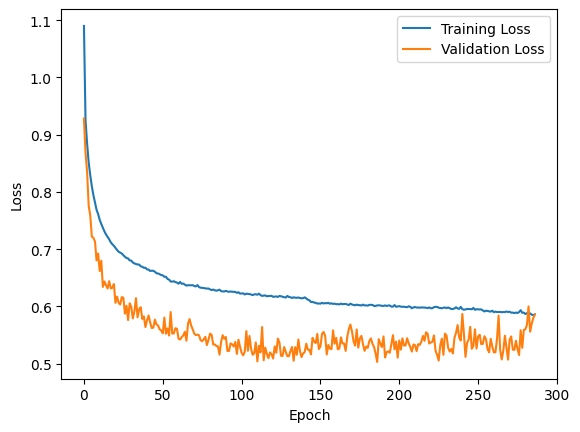

Scaler saved to scaler.pkl


In [98]:
history, scaler = train_base(model_data.copy(), patience=100, batch_size=256, validation_split=0.2, shuffle_seed=42, pretrain_epochs=2000)

plot_training_history(history)

save_scaler(scaler)

autoencoder: weights were loaded
Scaler loaded from scaler.pkl
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step 
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 246us/step


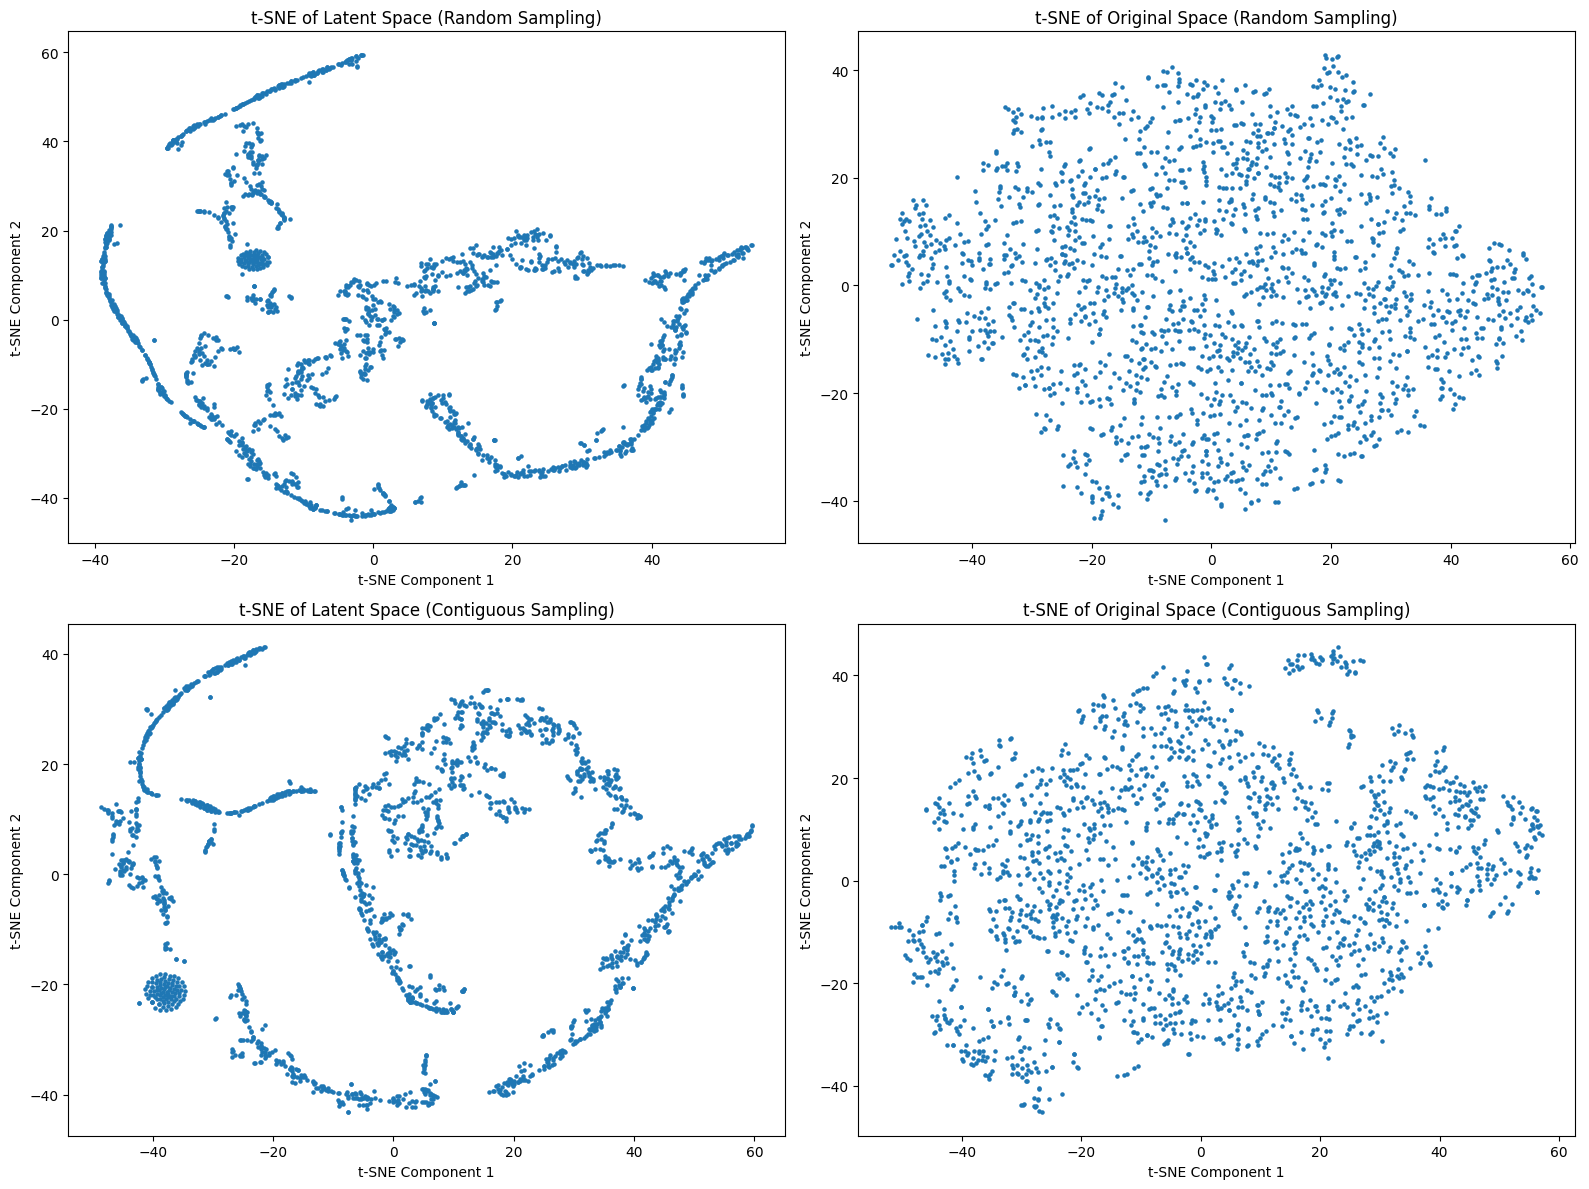

In [99]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from tensorflow.keras.models import Model

def get_encoder(model):
    bottleneck_layer_index = len(model.layers) // 2
    encoder = Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    return encoder

def plot_latent_and_original_space(model, df, scaler, sample_size=2000):
    df_scaled = scaler.transform(df)
    sample_indices = np.random.choice(df_scaled.shape[0], size=sample_size, replace=False)
    df_sampled_random = df_scaled[sample_indices]
    start_index = np.random.randint(0, df_scaled.shape[0] - sample_size)
    df_sampled_contiguous = df_scaled[start_index:start_index + sample_size]
    encoder = get_encoder(model)
    latent_representations_random = encoder.predict(df_sampled_random)
    latent_representations_contiguous = encoder.predict(df_sampled_contiguous)
    tsne_latent_random = TSNE(n_components=2, random_state=42)
    tsne_latent_results_random = tsne_latent_random.fit_transform(latent_representations_random)
    tsne_latent_contiguous = TSNE(n_components=2, random_state=42)
    tsne_latent_results_contiguous = tsne_latent_contiguous.fit_transform(latent_representations_contiguous)
    tsne_original_random = TSNE(n_components=2, random_state=42)
    tsne_original_results_random = tsne_original_random.fit_transform(df_sampled_random)
    tsne_original_contiguous = TSNE(n_components=2, random_state=42)
    tsne_original_results_contiguous = tsne_original_contiguous.fit_transform(df_sampled_contiguous)
    
    plt.figure(figsize=(16, 12))
    
    plt.subplot(2, 2, 1)
    plt.scatter(tsne_latent_results_random[:, 0], tsne_latent_results_random[:, 1], s=5, cmap='viridis')
    plt.title('t-SNE of Latent Space (Random Sampling)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    
    plt.subplot(2, 2, 2)
    plt.scatter(tsne_original_results_random[:, 0], tsne_original_results_random[:, 1], s=5, cmap='viridis')
    plt.title('t-SNE of Original Space (Random Sampling)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    
    plt.subplot(2, 2, 3)
    plt.scatter(tsne_latent_results_contiguous[:, 0], tsne_latent_results_contiguous[:, 1], s=5, cmap='viridis')
    plt.title('t-SNE of Latent Space (Contiguous Sampling)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    
    plt.subplot(2, 2, 4)
    plt.scatter(tsne_original_results_contiguous[:, 0], tsne_original_results_contiguous[:, 1], s=5, cmap='viridis')
    plt.title('t-SNE of Original Space (Contiguous Sampling)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    
    plt.tight_layout()
    plt.show()

autoencoder_model = auto_encoder(load_weights=True, weights_file= 'weight_final_gmm15.weights.h5')
scaler = load_scaler()
plot_latent_and_original_space(autoencoder_model, model_data, scaler)


autoencoder: weights file not found, training from scratch
Scaler loaded from scaler.pkl
34854/34854 ━━━━━━━━━━━━━━━━━━━━ 8s 210us/step


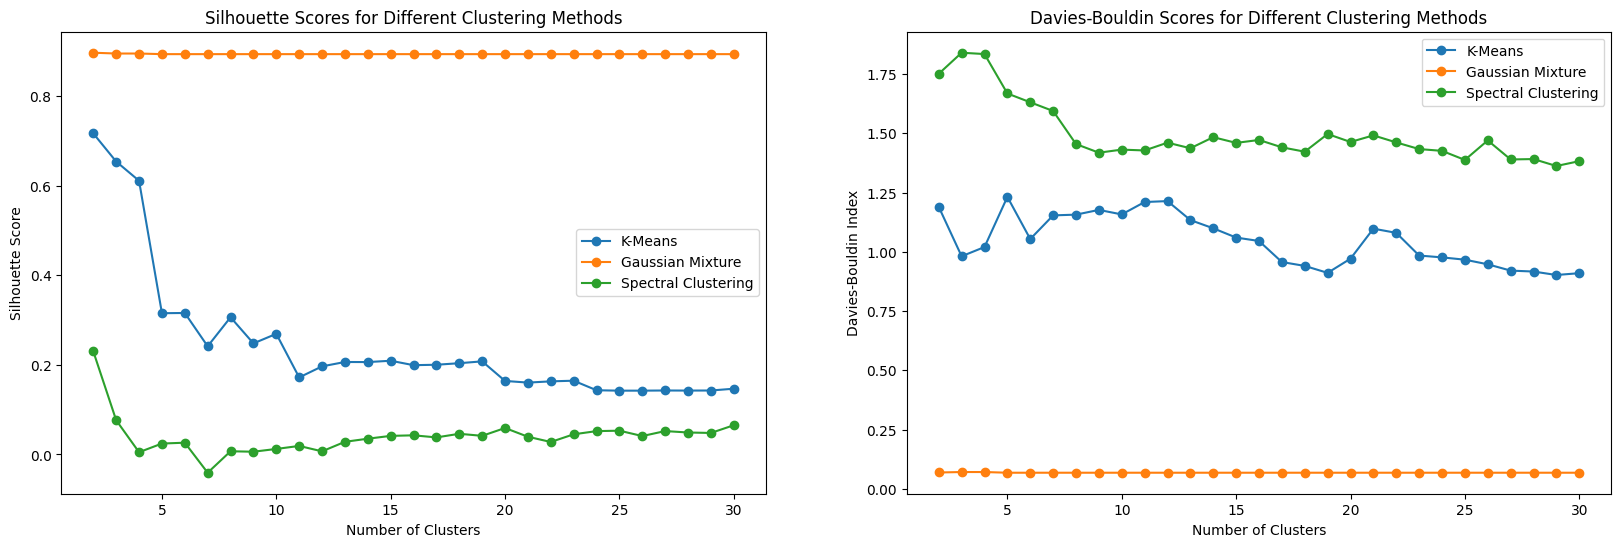

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
import pandas as pd
import os

def calculate_scores(data, labels):
    sil_score = silhouette_score(data, labels)
    db_score = davies_bouldin_score(data, labels)
    return sil_score, db_score

def run_kmeans(data, max_k):
    sil_scores = []
    db_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        sil_score, db_score = calculate_scores(data, labels)
        sil_scores.append(sil_score)
        db_scores.append(db_score)
    return sil_scores, db_scores

def run_gmm(data, max_k):
    sil_scores = []
    db_scores = []
    for k in range(2, max_k + 1):
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels = gmm.fit_predict(data)
        sil_score, db_score = calculate_scores(data, labels)
        sil_scores.append(sil_score)
        db_scores.append(db_score)
    return sil_scores, db_scores

def run_spectral(data, max_k):
    sil_scores = []
    db_scores = []
    for k in range(2, max_k + 1):
        spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
        labels = spectral.fit_predict(data)
        sil_score, db_score = calculate_scores(data, labels)
        sil_scores.append(sil_score)
        db_scores.append(db_score)
    return sil_scores, db_scores

def plot_elbow_curves(data, max_k=30):
    kmeans_sil, kmeans_db = run_kmeans(data, max_k)
    gmm_sil, gmm_db = run_gmm(data, max_k)
    spectral_sil, spectral_db = run_spectral(data, max_k)

    fig, axs = plt.subplots(1, 2, figsize=(20, 6))

    # Plot Silhouette Scores
    axs[0].plot(range(2, max_k + 1), kmeans_sil, marker='o', label='K-Means')
    axs[0].plot(range(2, max_k + 1), gmm_sil, marker='o', label='Gaussian Mixture')
    axs[0].plot(range(2, max_k + 1), spectral_sil, marker='o', label='Spectral Clustering')
    axs[0].set_xlabel('Number of Clusters')
    axs[0].set_ylabel('Silhouette Score')
    axs[0].set_title('Silhouette Scores for Different Clustering Methods')
    axs[0].legend()

    # Plot Davies-Bouldin Scores
    axs[1].plot(range(2, max_k + 1), kmeans_db, marker='o', label='K-Means')
    axs[1].plot(range(2, max_k + 1), gmm_db, marker='o', label='Gaussian Mixture')
    axs[1].plot(range(2, max_k + 1), spectral_db, marker='o', label='Spectral Clustering')
    axs[1].set_xlabel('Number of Clusters')
    axs[1].set_ylabel('Davies-Bouldin Index')
    axs[1].set_title('Davies-Bouldin Scores for Different Clustering Methods')
    axs[1].legend()

    plt.show()

def perform_clustering_analysis(model_data, weights_file):
    model = auto_encoder(load_weights=True, weights_file=weights_file)
    scaler = load_scaler()
    data_scaled = scaler.transform(model_data)

    bottleneck_layer_index = len(model.layers) // 2
    encoder = Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    latent_representations = encoder.predict(data_scaled)
    
    # Sample 5000 points
    sample_indices = np.random.choice(latent_representations.shape[0], size=500, replace=False)
    sampled_latent_representations = latent_representations[sample_indices]
    
    # Plot elbow curves
    plot_elbow_curves(sampled_latent_representations)

# Example usage
# Assuming df is your DataFrame containing the data
perform_clustering_analysis(model_data.copy(), 'weight_final_base.weights.h5')

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment as linear_assignment
import matplotlib.pyplot as plt
import os
import time
import csv
from tqdm import tqdm

def get_sil_db(assignments, features):
    sil_score = silhouette_score(features, assignments)
    db_score = davies_bouldin_score(features, assignments)
    return sil_score, db_score

def log_csv(strToWrite, file_name):
    path = r'log_history/'
    if not os.path.exists(path):
        os.makedirs(path)
    with open(path + file_name + '.csv', 'a+', encoding='utf-8') as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow(strToWrite)

def sorted_eig(X):
    e_vals, e_vecs = np.linalg.eig(X)  
    idx = np.argsort(e_vals)
    e_vecs = e_vecs[:, idx]
    e_vals = e_vals[idx]
    return e_vals, e_vecs

def train(x):
    ds_name = "kmeans"
    log_str = f'iter; sil_score, db_score, ri ; loss; n_changed_assignment; time:{time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())}'
    log_csv(log_str.split(';'), file_name=ds_name)
    model = auto_encoder(weights_file='weight_base.weights.h5')

    optimizer = tf.keras.optimizers.Adam()
    loss_value = 0
    index = 0
    kmeans_n_init = 10
    assignment = np.array([-1] * len(x))
    index_array = np.arange(x.shape[0])
    update_interval = 10 
    sil_score, db_index = 0, 0
    n_clusters = 7
    time_start = time.time()

    # Use tqdm for progress tracking
    for ite in tqdm(range(int(10)), desc="Training Progress"):

        # Recalculate V every 10 steps 
        if ite % update_interval == 0:
            H = model(x).numpy()[:, :hidden_units]  # Gets H
            ans_kmeans = KMeans(n_clusters=n_clusters, n_init=kmeans_n_init).fit(H)  # Fits KMeans to H
            
            # Number of times to run on different seeds (optional)
            kmeans_n_init = int(ans_kmeans.n_iter_ * 2)
            U = ans_kmeans.cluster_centers_  # Obtains mu, the centers
            assignment_new = ans_kmeans.labels_  # Array containing assignments for each element

            # This is the Hungarian algorithm for cluster assignment
            w = np.zeros((n_clusters, n_clusters), dtype=np.int64)  # Sets up adjacency matrix
            for i in range(len(assignment_new)):
                w[assignment_new[i], assignment[i]] += 1

            # This does the Hungarian algorithm
            ind = linear_assignment(-w)

            # Changes the associated clusters
            temp = np.array(assignment)
            for i in range(n_clusters):
                assignment[temp == ind[1][i]] = i

            # Number of changes
            n_change_assignment = np.sum(assignment_new != assignment)
            assignment = assignment_new

            # Gets total within sum of squares matrix
            S_i = []
            for i in range(n_clusters):
                temp = H[assignment == i] - U[i]
                temp = np.matmul(np.transpose(temp), temp)
                S_i.append(temp)
            S_i = np.array(S_i)
            S = np.sum(S_i, 0)

            Evals, V = sorted_eig(S)
            H_vt = np.matmul(H, V)  # Finds y = Vh
            U_vt = np.matmul(U, V)  # Finds m = Vmu 

            loss = np.round(np.mean(loss_value), 8)

            # Calculate Silhouette Score and Davies-Bouldin Index
            # sil_score, db_index = silhouette_score(H, assignment), davies_bouldin_score(H, assignment)
            #
            # Log
            log_str = f'iter {ite // update_interval}; sil_score, db_score, ri = {sil_score, db_index}; loss:' \
                      f'{loss}; n_changed_assignment:{n_change_assignment}; time:{time.time() - time_start:.3f}'
            print(log_str)
            log_csv(log_str.split(';'), file_name=ds_name)

        # Stopping condition

        # Getting next batch
        idx = index_array[index * batch_size: min((index + 1) * batch_size, x.shape[0])]

        # Creating y' from y & replacing last dimension of y' with m_i
        y_true = H_vt[idx]  # y: latent representations for the current batch
        temp = assignment[idx]  # m_i: cluster assignments for the current batch
        for i in range(len(idx)):
            y_true[i, -1] = U_vt[temp[i], -1]  # Creating y': replacing last dimension with m_i

        # Update all model variables
        with tf.GradientTape() as tape:
            y_pred = model(x[idx])  # h
            y_pred_cluster = tf.matmul(y_pred[:, :hidden_units], V)  # y = Vh
            loss_value = tf.keras.losses.mse(y_true, y_pred_cluster)
        grads = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
        index = index + 1 if (index + 1) * batch_size <= x.shape[0] else 0

        if n_change_assignment <= len(x) * 0.001 or (ite - 10 > 0 and loss == 0):
            break

    model.save_weights(f'weight_final_{ds_name}.weights.h5')
    print(f'end saved to weight_final_{ds_name}.weights.h5')

# Assuming x_scaled is the scaled data in numpy format
scaler = load_scaler()
x_scaled = scaler.transform(model_data.copy())
train(x_scaled)

Scaler loaded from scaler.pkl
autoencoder: weights were loaded


Training Progress:  10%|███████                                                               | 1/10 [00:07<01:03,  7.10s/it]

iter 0; sil_score, db_score, ri = (0, 0); loss:0.0; n_changed_assignment:1115367; time:6.974


Training Progress: 100%|█████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.34it/s]

end saved to weight_final_kmeans.weights.h5


Scaler loaded from scaler.pkl
autoencoder: weights were loaded
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/var/folders/mx/w2wt265x26n5z_26swrbljww0000gn/T/ipykernel_19466/1731825831.py:23: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



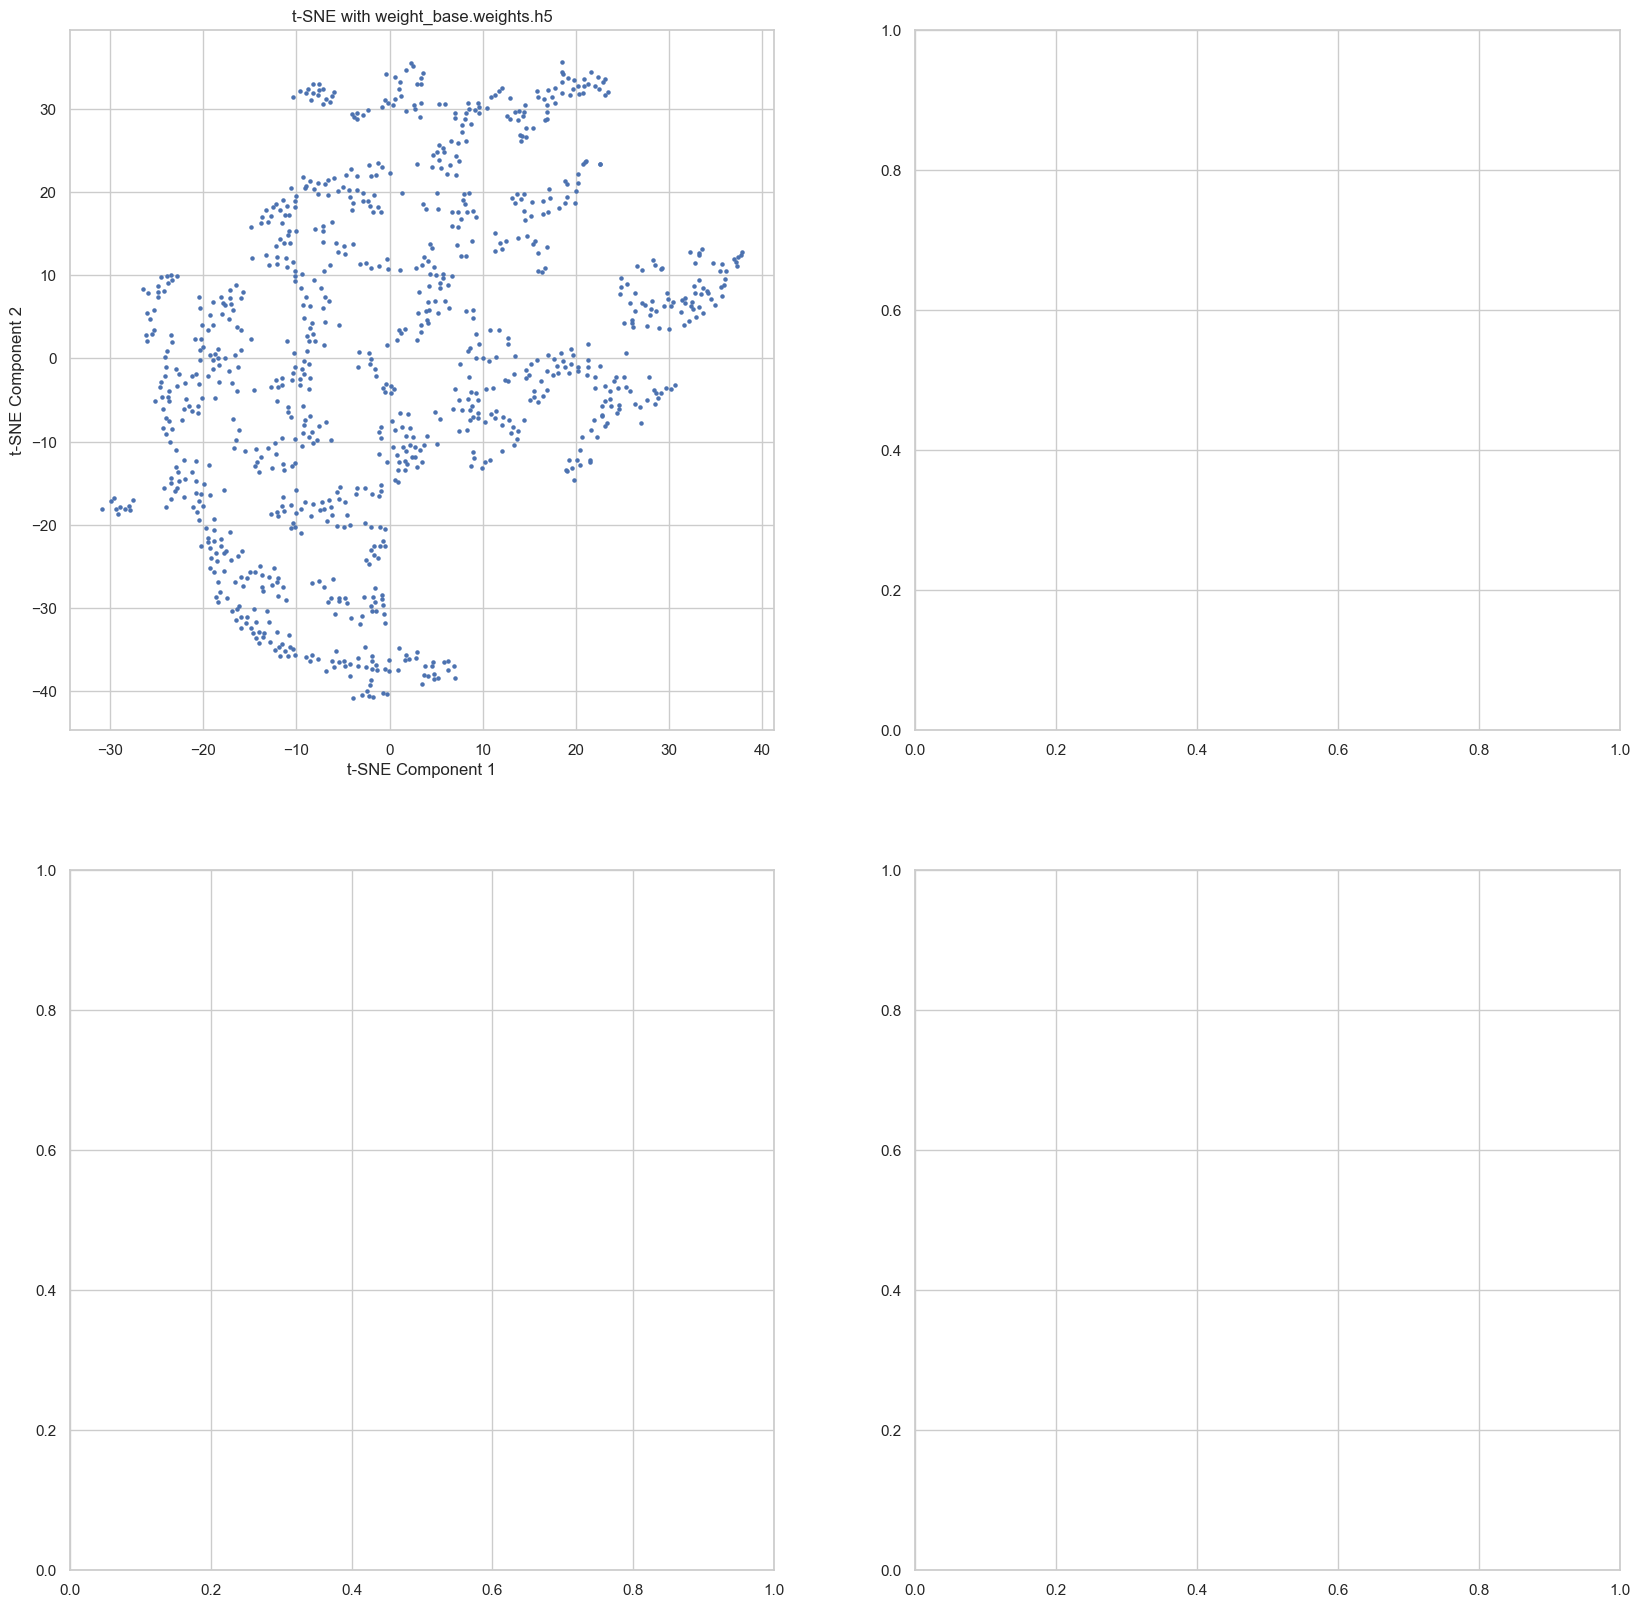

In [147]:
from sklearn.manifold import TSNE

def perform_tsne_and_plot(model, data, scaler, ax, title):
    # Randomly sample 2000 points from the dataset
    sample_indices = np.random.choice(data.index, size=1000, replace=False)
    sampled_data = data.loc[sample_indices]
    
    # Scale the sampled data
    sampled_data_scaled = scaler.transform(sampled_data)
    
    # Get the latent representations
    bottleneck_layer_index = len(model.layers) // 2
    
    # Create the encoder model
    encoder = Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    latent_representations = encoder.predict(sampled_data_scaled)
    
    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(latent_representations)
    
    # Plot the t-SNE results
    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], s=5, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
scaler = load_scaler()
# Create the subplots
fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Perform t-SNE and plot the clusters for base and three sets of weights
perform_tsne_and_plot(
    model=auto_encoder(load_weights=True, weights_file='weight_base.weights.h5'), 
    data=model_data.copy(), 
    scaler=scaler, 
    ax=axs[0, 0], 
    title='t-SNE with weight_base.weights.h5'
)

perform_tsne_and_plot(
    model=auto_encoder(load_weights=True, weights_file='weight_final_kmeans.weights.h5'), 
    data=model_data.copy(), 
    scaler=scaler, 
    ax=axs[0, 1], 
    title='t-SNE with weight_final_kmeans.weights.h5'
)

perform_tsne_and_plot(
    model=auto_encoder(load_weights=True, weights_file='weight_final_gmm.weights.h5'), 
    data=model_data.copy(), 
    scaler=scaler, 
    ax=axs[1, 0], 
    title='t-SNE with weight_final_gmm.weights.h5'
)

perform_tsne_and_plot(
    model=auto_encoder(load_weights=True, weights_file='weight_final_spectral.weights.h5'), 
    data=model_data.copy(), 
    scaler=scaler, 
    ax=axs[1, 1], 
    title='t-SNE with weight_final_spectral.weights.h5'
)

plt.tight_layout()
plt.show()

In [180]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, KernelPCA
from sklearn.mixture import GaussianMixture
from keras.models import Model
import matplotlib.pyplot as plt

def perform_tsne_and_plot(latent_representations, cluster_labels, ax, title):
    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(latent_representations)
    
    # Plot the t-SNE results
    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=cluster_labels, s=5, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')

scaler = load_scaler()

# Randomly sample 1000 points from the dataset
sample_indices = np.random.choice(model_data.index, size=1000, replace=False)
sampled_data = model_data.loc[sample_indices]
sampled_data_scaled = scaler.transform(sampled_data)

# Load the autoencoders
base_model = auto_encoder(load_weights=True, weights_file='weight_base.weights.h5')
kmeans_model = auto_encoder(load_weights=True, weights_file='weight_final_kmeans.weights.h5')
gmm_model = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')

# Get latent representations
def get_latent_representations(model, data_scaled):
    bottleneck_layer_index = len(model.layers) // 2
    encoder = Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    return encoder.predict(data_scaled)

latent_base = get_latent_representations(base_model, sampled_data_scaled)
latent_kmeans = get_latent_representations(kmeans_model, sampled_data_scaled)
latent_gmm = get_latent_representations(gmm_model, sampled_data_scaled)

# Perform PCA and Kernel PCA
pca = PCA(n_components=6)
pca_latent = pca.fit_transform(sampled_data_scaled)

kpca = KernelPCA(n_components=6, kernel='rbf')
kpca_latent = kpca.fit_transform(sampled_data_scaled)

# Fit Gaussian Mixture Model
def fit_gmm(latent_space):
    gmm = GaussianMixture(n_components=6, random_state=42)
    gmm.fit(latent_space)
    return gmm.predict(latent_space)

cluster_base = fit_gmm(latent_base)
cluster_kmeans = fit_gmm(latent_kmeans)
cluster_gmm = fit_gmm(latent_gmm)
cluster_pca = fit_gmm(pca_latent)
cluster_kpca = fit_gmm(kpca_latent)

# Create the subplots
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Perform t-SNE and plot the clusters for each latent space
perform_tsne_and_plot(latent_base, cluster_base, axs[0], 't-SNE with Base Weights')
perform_tsne_and_plot(latent_kmeans, cluster_kmeans, axs[1], 't-SNE with K-means Weights')
perform_tsne_and_plot(latent_gmm, cluster_gmm, axs[2], 't-SNE with GMM Weights')
perform_tsne_and_plot(pca_latent, cluster_pca, axs[3], 'PCA with GMM Clustering')
perform_tsne_and_plot(kpca_latent, cluster_kpca, axs[4], 'Kernel PCA with GMM Clustering')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('comparison_plot.png')


Scaler loaded from scaler.pkl
autoencoder: weights were loaded


In [181]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
import plotly.express as px
import plotly.io as pio

# Ensure plotly renders properly in your environment
pio.renderers.default = "browser"  # or "browser" if running outside of a notebook


def get_encoder(model):
    # Find the index of the bottleneck layer
    bottleneck_layer_index = len(model.layers) // 2
    
    # Create the encoder model
    encoder = Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    return encoder

def plot_hidden_layer_tsne_3d_interactive(model, df, scaler, sample_size=5000):
    # Normalize the data using the provided scaler
    df_scaled = scaler.transform(df)
    
    # Randomly sample a subset of the data
    sample_indices = np.random.choice(df_scaled.shape[0], size=sample_size, replace=False)
    df_sampled_random = df_scaled[sample_indices]
    
    # Get the encoder part of the autoencoder
    encoder = get_encoder(model)
    
    # Predict the latent representations for the sampled data
    latent_representations = encoder.predict(df_sampled_random)
    
    # Apply t-SNE to reduce the dimensionality of the latent space to 3D
    tsne_latent = TSNE(n_components=3, random_state=42)
    tsne_latent_results = tsne_latent.fit_transform(latent_representations)
    
    # Create a DataFrame for plotting
    tsne_latent_df = pd.DataFrame(tsne_latent_results, columns=['Component 1', 'Component 2', 'Component 3'])
    
    # Plot the 3D t-SNE results for latent space using plotly
    fig = px.scatter_3d(tsne_latent_df, x='Component 1', y='Component 2', z='Component 3', title='3D t-SNE of Latent Space')
    fig.show()

# Example usage
autoencoder_model = auto_encoder(load_weights=True, weights_file= 'weight_final_gmm15.weights.h5')  # Ensure this is the trained model
plot_hidden_layer_tsne_3d_interactive(autoencoder_model, model_data, scaler)


autoencoder: weights were loaded
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step


Python(24055) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [18]:
import numpy as np
import tensorflow as tf
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.manifold import TSNE
import pandas as pd
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
import plotly.io as pio
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture




# Sample a continuous section of 1000 data points
start_index = np.random.randint(0, len(model_data) - 10000)
sampled_data = model_data.iloc[start_index:start_index + 10000]
sampled_ohlc = ohlc_data.iloc[start_index:start_index + 10000]
pio.renderers.default = "browser"  # or "browser" if running outside of a notebook

def plot_ohlc_with_clustering(sampled_data, sampled_ohlc, method='kmeans', n_clusters=7):
    # Scale the sampled data
    scaler = load_scaler()
    sampled_data_scaled = scaler.fit_transform(sampled_data)

    # Load the autoencoder model
    model = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')

    # Get the latent representations
    bottleneck_layer_index = len(model.layers) // 2
    encoder = tf.keras.Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
    latent_representations = encoder.predict(sampled_data_scaled)

    # Apply the specified clustering method
    if method == 'kmeans':
        clustering_model = KMeans(n_clusters=n_clusters, random_state=42)
    elif method == 'gmm':
        clustering_model = GaussianMixture(n_components=n_clusters, random_state=42)
    elif method == 'spectral':
        clustering_model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    elif method == 'agglomerative':
        clustering_model = AgglomerativeClustering(n_clusters=n_clusters)
    else:
        raise ValueError("Unsupported clustering method. Choose from 'kmeans', 'gmm', 'spectral', 'agglomerative'.")

    if method == 'gmm':
        labels = clustering_model.fit_predict(latent_representations)
    else:
        labels = clustering_model.fit_predict(latent_representations)

    # Ensure 'datetime' and 'close' columns are properly formatted
    sampled_ohlc['datetime'] = pd.to_datetime(sampled_ohlc['datetime'])
    if not pd.api.types.is_datetime64_any_dtype(sampled_ohlc['datetime']):
        raise ValueError("The 'datetime' column is not in datetime format.")

    if 'close' not in sampled_ohlc.columns:
        raise KeyError("The 'close' column is not present in the DataFrame.")

    # Create a Plotly figure
    fig = go.Figure()

    # Add OHLC data
    fig.add_trace(go.Candlestick(x=sampled_ohlc['datetime'],
                                 open=sampled_ohlc['open'],
                                 high=sampled_ohlc['high'],
                                 low=sampled_ohlc['low'],
                                 close=sampled_ohlc['close']))

    # Add clustering results as scatter plot
    colors = ['red', 'blue', 'pink', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'black']
    for i in range(len(sampled_ohlc)):
        fig.add_trace(go.Scatter(x=[sampled_ohlc['datetime'].iloc[i]],
                                 y=[sampled_ohlc['close'].iloc[i]],
                                 mode='markers',
                                 marker=dict(color=colors[labels[i] % len(colors)], size=10),
                                 showlegend=False))

    # Update layout
    fig.update_layout(
        title=f'OHLC with {method.capitalize()} Clustering',
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False
    )

    # Show the plot
    fig.show()


# Sample a continuous section of 1000 data points
start_index = np.random.randint(0, len(model_data) - 5000)
sampled_data = model_data.iloc[start_index:start_index + 5000]
sampled_ohlc = ohlc_data.iloc[start_index:start_index + 5000]
pio.renderers.default = "browser"

# Plot with the specified clustering method
plot_ohlc_with_clustering(sampled_data, sampled_ohlc, method='spectral', n_clusters=8)

Scaler loaded from scaler.pkl
autoencoder: weights were loaded
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step


/var/folders/mx/w2wt265x26n5z_26swrbljww0000gn/T/ipykernel_4829/2206324012.py:52: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [42]:
from sklearn.mixture import GaussianMixture

def fit_gmm_with_autoencoder(model_data, n_components=10, n_points=200000):
    # Scale the model data
    scaler = load_scaler()
    model_data_scaled = scaler.transform(model_data)

    autoencoder = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')

    bottleneck_layer_index = len(autoencoder.layers) // 2
    encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[bottleneck_layer_index].output)
    latent_representations = encoder.predict(model_data_scaled[:n_points])

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(latent_representations)

    return gmm, autoencoder

# Example usage
gmm_model, autoencoder_model = fit_gmm_with_autoencoder(model_data, n_components=6, n_points=500000)

Scaler loaded from scaler.pkl
autoencoder: weights were loaded
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 3s 208us/step


In [43]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Assuming model_data and ohlc_data are predefined pandas DataFrames
print(ohlc_data.shape)
print(model_data.shape)

start_index = np.random.randint(0, len(model_data) - 5000)
sampled_data = model_data.iloc[start_index:start_index + 5000]
sampled_ohlc = ohlc_data.iloc[start_index:start_index + 5000]
pio.renderers.default = "browser"

scaler = load_scaler()
sampled_data_scaled = scaler.transform(sampled_data)

# Load the autoencoder model (assuming auto_encoder and load_weights functions are defined)
model = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')

# Get the latent representations
bottleneck_layer_index = len(model.layers) // 2
encoder = tf.keras.Model(inputs=model.input, outputs=model.layers[bottleneck_layer_index].output)
latent_representations = encoder.predict(sampled_data_scaled)

# Assuming gmm_model is predefined and fitted
labels = gmm_model.predict(latent_representations)

# Ensure 'datetime' and 'close' columns are properly formatted
sampled_ohlc['datetime'] = pd.to_datetime(sampled_ohlc['datetime'])
if not pd.api.types.is_datetime64_any_dtype(sampled_ohlc['datetime']):
    raise ValueError("The 'datetime' column is not in datetime format.")

if 'close' not in sampled_ohlc.columns:
    raise KeyError("The 'close' column is not present in the DataFrame.")

# Create a Plotly figure
fig = go.Figure()

# Add OHLC data
fig.add_trace(go.Candlestick(x=sampled_ohlc['datetime'],
                             open=sampled_ohlc['open'],
                             high=sampled_ohlc['high'],
                             low=sampled_ohlc['low'],
                             close=sampled_ohlc['close']))

# Add clustering results as scatter plot
colors = ['red', 'blue', 'pink', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'black']
cluster_labels = np.unique(labels)
for cluster_label in cluster_labels:
    indices = np.where(labels == cluster_label)[0]
    fig.add_trace(go.Scatter(x=sampled_ohlc['datetime'].iloc[indices],
                             y=sampled_ohlc['close'].iloc[indices],
                             mode='markers',
                             marker=dict(color=colors[cluster_label % len(colors)], size=10),
                             name=f'Cluster {cluster_label}'))

# Update layout
fig.update_layout(
    title='OHLC with GMM Clustering',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False
)

# Show the plot
fig.show()


(1115317, 5)
(1115317, 66)
Scaler loaded from scaler.pkl
autoencoder: weights were loaded
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step


/var/folders/mx/w2wt265x26n5z_26swrbljww0000gn/T/ipykernel_4829/1161114698.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Starting Capital: 12986.2
autoencoder: weights were loaded
Scaler loaded from scaler.pkl
34854/34854 ━━━━━━━━━━━━━━━━━━━━ 7s 206us/step
1115317
1115317


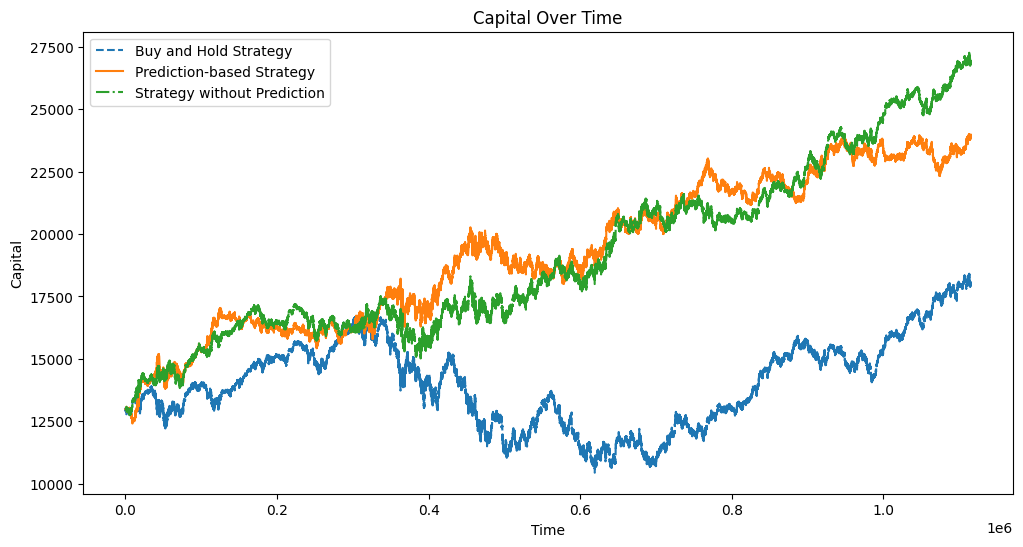

Prediction-based Strategy Percentage Return: 84.51%
Strategy without Prediction Percentage Return: 107.20%
Number of Days: 808.20
Number of Months: 36.74


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

def simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, use_prediction):
    initial_price = X_test[0]
    capital = initial_price
    capital_over_time = [initial_price]
    
    buy_and_hold_value = initial_price
    buy_and_hold_over_time = [initial_price]

    in_trade = False
    trade_type = None  # 1 for long, 0 for short

    long_trigger_value = 43
    short_trigger_value = -60
    stop_value = -120
    gain_value = 40

    sum_bull = 0
    sum_bear = 0
    accumulative_sum_pos = 0
    accumulative_sum_neg = 0
    prev_pos = 0
    prev_neg = 0

    prev_price = 0

    long_stop = False
    short_stop = False

    for i in range(1, len(X_test)):
        current_price = X_test[i]
        prev_price = X_test[i - 1]
        price_change = current_price - prev_price

        buy_and_hold_value += price_change
        buy_and_hold_over_time.append(buy_and_hold_value)

        prev_neg = accumulative_sum_neg
        prev_pos = accumulative_sum_pos

        if price_change > 0:
            accumulative_sum_pos += price_change
            accumulative_sum_neg = 0
        elif price_change < 0:
            accumulative_sum_neg += price_change
            accumulative_sum_pos = 0

        sum_bull = prev_pos if (prev_pos > 0 and accumulative_sum_pos == 0) else 0
        sum_bear = prev_neg if (prev_neg < 0 and accumulative_sum_neg == 0) else 0

        if use_prediction and (i-1) % 15 == 0:
            up = pred[((i-1)//15)] >= 6
            down = not up
            
            if up and trade_type == 0:  
                short_stop = True
            else:
                short_stop = False
            if down and trade_type == 1:  # Short trade and market is dec
                long_stop = True
            else:
                long_stop = False

        if sum_bull > long_trigger_value:
            if in_trade and trade_type == 0:
                ret = trade_entry_price - current_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price + stop_value
                highest_since_entry = current_price
                trade_type = 1
                in_trade = True

        elif sum_bear < short_trigger_value:
            if in_trade and trade_type == 1:
                ret = current_price - trade_entry_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price - stop_value
                lowest_since_entry = current_price
                trade_type = 0
                in_trade = True

        if in_trade:
            if trade_type == 1:  # Long position
                if current_price - trade_entry_price >= gain_value:
                    stop_loss_price = max(stop_loss_price, current_price + stop_value)
                highest_since_entry = max(highest_since_entry, current_price)
                if long_stop and current_price <= stop_loss_price:
                    ret = current_price - trade_entry_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price - stop_value
                        lowest_since_entry = current_price
                        trade_type = 0
                        in_trade = True

            elif trade_type == 0:  # Short position
                if trade_entry_price - current_price >= gain_value:
                    stop_loss_price = min(stop_loss_price, current_price - stop_value)
                lowest_since_entry = min(lowest_since_entry, current_price)
                if short_stop and current_price >= stop_loss_price:
                    ret = trade_entry_price - current_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price + stop_value
                        highest_since_entry = current_price
                        trade_type = 1
                        in_trade = True

        trade_value = capital
        if in_trade:
            trade_value += current_price - trade_entry_price if trade_type == 1 else trade_entry_price - current_price

        capital_over_time.append(trade_value)

        if not in_trade:
            highest_since_entry = 0
            lowest_since_entry = 0

    return capital_over_time, buy_and_hold_over_time

# Usage example with your data
j = 0
test_closes = np.array(ohlc_data_ori['close'][j:])
print(f"Starting Capital: {test_closes[0]}")

initial_capital = test_closes[0]
tc = 1.5
stop_loss_pct = 0.10 

autoencoder = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')
scaler = load_scaler()
model_data_scaled = scaler.transform(model_data)
bottleneck_layer_index = len(autoencoder.layers) // 2
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[bottleneck_layer_index].output)
latent_representations = encoder.predict(model_data_scaled)
pred = gmm_model.predict(latent_representations).astype(np.int32)

print(len(pred))
print(len(test_closes))

# Simulate the three strategies
capital_pred, buy_and_hold = simulate_trading_strategy(test_closes, pred, tc, stop_loss_pct, use_prediction=True)
capital_no_pred, _ = simulate_trading_strategy(test_closes, pred, tc, stop_loss_pct, use_prediction=False)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(buy_and_hold, label='Buy and Hold Strategy', linestyle='--')
plt.plot(capital_pred, label='Prediction-based Strategy')
plt.plot(capital_no_pred, label='Strategy without Prediction', linestyle='-.')
plt.title('Capital Over Time')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.legend()
plt.show()

percentage_return_pred = ((capital_pred[-1] - initial_capital) * 100) / initial_capital
percentage_return_no_pred = ((capital_no_pred[-1] - initial_capital) * 100) / initial_capital
number_of_days = len(test_closes) / 1380

print(f"Prediction-based Strategy Percentage Return: {percentage_return_pred:.2f}%")
print(f"Strategy without Prediction Percentage Return: {percentage_return_no_pred:.2f}%")
print(f"Number of Days: {number_of_days:.2f}")
print(f"Number of Months: {number_of_days/22:.2f}")

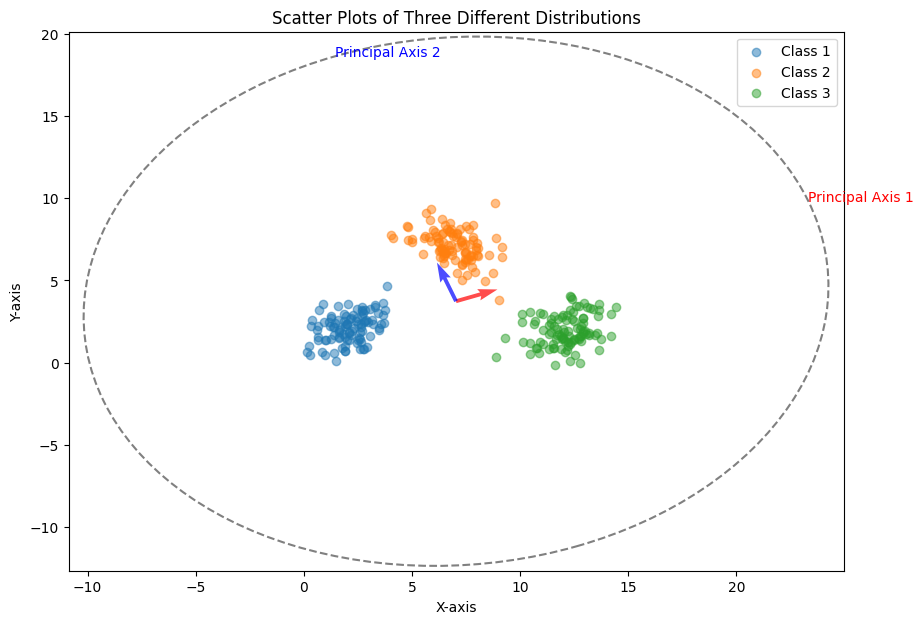

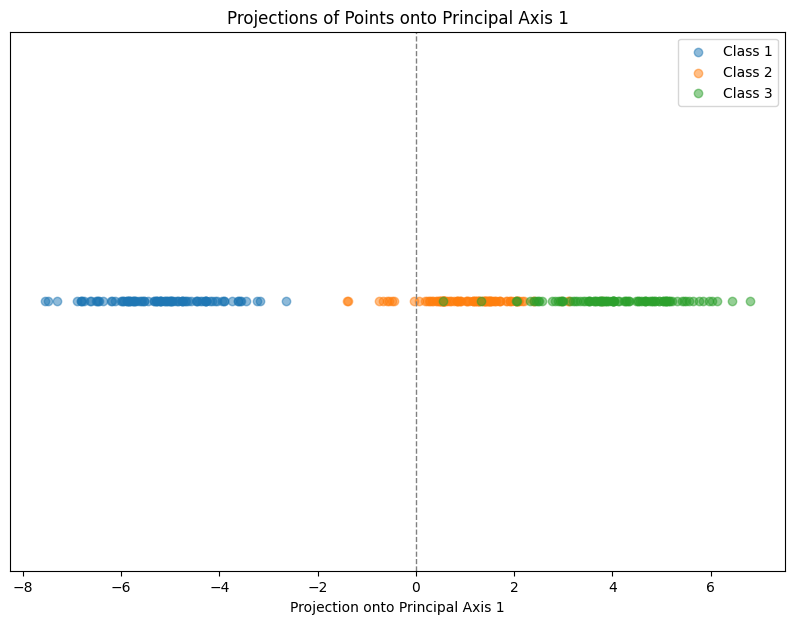

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig
from matplotlib.patches import Ellipse

# Generate data for three different distributions
np.random.seed(42)
mean1, cov1, size1 = [2, 2], [[1, 0.5], [0.5, 1]], 100
mean2, cov2, size2 = [7, 7], [[1, -0.3], [-0.3, 1]], 100
mean3, cov3, size3 = [12, 2], [[1, 0.2], [0.2, 1]], 100

data1 = np.random.multivariate_normal(mean1, cov1, size1)
data2 = np.random.multivariate_normal(mean2, cov2, size2)
data3 = np.random.multivariate_normal(mean3, cov3, size3)

# Plot the data
plt.figure(figsize=(10, 7))
plt.scatter(data1[:, 0], data1[:, 1], label='Class 1', alpha=0.5)
plt.scatter(data2[:, 0], data2[:, 1], label='Class 2', alpha=0.5)
plt.scatter(data3[:, 0], data3[:, 1], label='Class 3', alpha=0.5)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Scatter Plots of Three Different Distributions')

# Compute within-class scatter matrices
S1 = np.cov(data1, rowvar=False) * (size1 - 1)
S2 = np.cov(data2, rowvar=False) * (size2 - 1)
S3 = np.cov(data3, rowvar=False) * (size3 - 1)

# Total within-class scatter matrix
Sw = S1 + S2 + S3

# Eigen decomposition
eigenvalues, eigenvectors = eig(Sw)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Visualize the total within-class scatter matrix
mean_combined = np.mean(np.vstack((data1, data2, data3)), axis=0)
angle = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])

# Scale eigenvalues to make the ellipsoid tighter
scaling_factor = np.sqrt(eigenvalues)

# Plot ellipse
ellipse = Ellipse(mean_combined, scaling_factor[0] * 2, scaling_factor[1] * 2, 
                  angle=np.degrees(angle), edgecolor='grey', facecolor='none', linestyle='dashed', linewidth=1.5)
plt.gca().add_patch(ellipse)

# Add principal axes scaled to touch the ellipse
plt.quiver(mean_combined[0], mean_combined[1], eigenvectors[0, 0] * scaling_factor[0], eigenvectors[1, 0] * scaling_factor[0],
           color='red', alpha=0.7, scale_units='xy', angles='xy', width=0.005)
plt.quiver(mean_combined[0], mean_combined[1], eigenvectors[0, 1] * scaling_factor[1], eigenvectors[1, 1] * scaling_factor[1],
           color='blue', alpha=0.7, scale_units='xy', angles='xy', width=0.005)

# Add labels for the principal axes
plt.text(mean_combined[0] + eigenvectors[0, 0] * scaling_factor[0], mean_combined[1] + eigenvectors[1, 0] * scaling_factor[0],
         'Principal Axis 1', color='red')
plt.text(mean_combined[0] + eigenvectors[0, 1] * scaling_factor[1], mean_combined[1] + eigenvectors[1, 1] * scaling_factor[1],
         'Principal Axis 2', color='blue')

plt.legend(['Class 1', 'Class 2', 'Class 3'])
plt.savefig('scatter.png')
plt.show()

# Project the data onto the first principal axis
proj1 = np.dot(data1 - mean_combined, eigenvectors[:, 0])
proj2 = np.dot(data2 - mean_combined, eigenvectors[:, 0])
proj3 = np.dot(data3 - mean_combined, eigenvectors[:, 0])

# Plot the projections onto the first principal axis
plt.figure(figsize=(10, 7))
plt.scatter(proj1, np.zeros_like(proj1), label='Class 1', alpha=0.5, color='C0')
plt.scatter(proj2, np.zeros_like(proj2), label='Class 2', alpha=0.5, color='C1')
plt.scatter(proj3, np.zeros_like(proj3), label='Class 3', alpha=0.5, color='C2')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Projection onto Principal Axis 1')
plt.yticks([])
plt.legend()
plt.title('Projections of Points onto Principal Axis 1')
plt.savefig('pca_scatter.png')
plt.show()


## Optimize

autoencoder: weights were loaded
Scaler loaded from scaler.pkl
34854/34854 ━━━━━━━━━━━━━━━━━━━━ 7s 207us/step
(True, True, True, True, True, True) 122.95744713619067
(True, True, True, True, True, False) 128.6696647210119
(True, True, True, True, False, True) 115.28776701421567
(True, True, True, True, False, False) 124.7270179113214
(True, True, True, False, True, True) 123.09759590950411
(True, True, True, False, True, False) 129.3935100337281
(True, True, True, False, False, True) 121.96100475889803
(True, True, True, False, False, False) 130.36223067564032
(True, True, False, True, True, True) 129.70614960496525
(True, True, False, True, True, False) 133.8074263448894
(True, True, False, True, False, True) 134.33105912430136
(True, True, False, True, False, False) 138.45697740678594
(True, True, False, False, True, True) 130.55166253407424
(True, True, False, False, True, False) 140.56382929571384
(True, True, False, False, False, True) 135.72022608615296
(True, True, False, False,

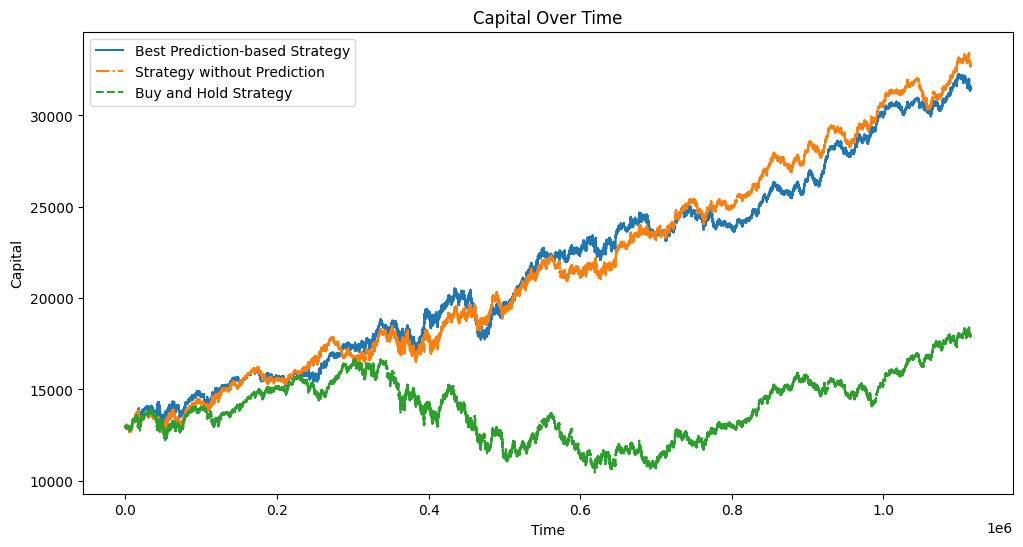

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import random
import itertools


def simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config, look_back_start=15, look_back_end=136, use_prediction=True):
    initial_price = X_test[0]
    capital = initial_price
    capital_over_time = [initial_price]
    
    buy_and_hold_value = initial_price
    buy_and_hold_over_time = [initial_price]

    in_trade = False
    trade_type = None  # 1 for long, 0 for short

    long_trigger_value = 43
    short_trigger_value = -60


    sum_bull = 0
    sum_bear = 0
    accumulative_sum_pos = 0
    accumulative_sum_neg = 0
    prev_pos = 0
    prev_neg = 0

    short_stop = False
    long_stop = False

    prev_price = 0

    for i in range(1, len(X_test)):
        current_price = X_test[i]
        prev_price = X_test[i - 1]
        price_change = current_price - prev_price

        buy_and_hold_value += price_change
        buy_and_hold_over_time.append(buy_and_hold_value)

        prev_neg = accumulative_sum_neg
        prev_pos = accumulative_sum_pos

        if price_change > 0:
            accumulative_sum_pos += price_change
            accumulative_sum_neg = 0
        elif price_change < 0:
            accumulative_sum_neg += price_change
            accumulative_sum_pos = 0

        sum_bull = prev_pos if (prev_pos > 0 and accumulative_sum_pos == 0) else 0
        sum_bear = prev_neg if (prev_neg < 0 and accumulative_sum_neg == 0) else 0

        # Calculate the look-back window highest and lowest close prices
        if i >= look_back_end:
            look_back_window = X_test[i - look_back_end:i - look_back_start + 1]
            highest_close = np.max(look_back_window)
            lowest_close = np.min(look_back_window)
        else:
            highest_close = np.inf
            lowest_close = -np.inf

        if use_prediction and (i - 1) % 1 == 0:
            cluster = pred[((i - 1) // 1)]
            up = stop_loss_config[cluster]
            down = not up

            if up and trade_type == 0:  # Short trade and market is rising
                short_stop = True
            else:
                short_stop = False
                
            if down and trade_type == 1:  # Long trade and market is falling
                long_stop = True
            else:
                long_stop = False

        if sum_bull > long_trigger_value and current_price < highest_close:
            if in_trade and trade_type == 0:
                ret = trade_entry_price - current_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price * (1 - stop_loss_pct)  # Fixed stop loss
                highest_since_entry = current_price
                trade_type = 1
                in_trade = True

        elif sum_bear < short_trigger_value and current_price < lowest_close:
            if in_trade and trade_type == 1:
                ret = current_price - trade_entry_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price * (1 + stop_loss_pct)  # Fixed stop loss
                lowest_since_entry = current_price
                trade_type = 0
                in_trade = True

        if in_trade:
            if trade_type == 1:  # Long position
                if long_stop and( current_price <= stop_loss_price):
                    ret = current_price - trade_entry_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price * (1 + stop_loss_pct)  # Fixed stop loss
                        lowest_since_entry = current_price
                        trade_type = 0
                        in_trade = True

            elif trade_type == 0:  # Short position
                if short_stop and (current_price >= stop_loss_price):
                    ret = trade_entry_price - current_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price * (1 - stop_loss_pct)  # Fixed stop loss
                        highest_since_entry = current_price
                        trade_type = 1
                        in_trade = True

        trade_value = capital
        if in_trade:
            trade_value += current_price - trade_entry_price if trade_type == 1 else trade_entry_price - current_price

        capital_over_time.append(trade_value)

        if not in_trade:
            highest_since_entry = 0
            lowest_since_entry = 0

    return capital_over_time, buy_and_hold_over_time

def optimize_strategy(X_test, pred, tc, stop_loss_pct):
    best_return = -np.inf
    best_config = None
    best_capital_over_time = None

    # Generate all possible permutations in lexicographic order
    num_clusters = len(np.unique(pred))
    all_permutations = list(itertools.product([True, False], repeat=num_clusters))
    
    for stop_loss_config in all_permutations:
        capital_pred, _ = simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config)
        final_capital = capital_pred[-1]

        percentage_return = ((final_capital - X_test[0]) * 100) / X_test[0]
        print(stop_loss_config, percentage_return)


        if percentage_return > best_return:
            best_return = percentage_return
            best_config = stop_loss_config
            best_capital_over_time = capital_pred
    
    return best_config, best_return, best_capital_over_time

# Example usage
j = 0
test_closes = np.array(ohlc_data_ori['close'][j:])
initial_capital = test_closes[0]
tc = 1.5
stop_loss_pct = 0.006  # 0.6% as a decimal
num_permutations = 100

autoencoder = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')
scaler = load_scaler()
model_data_scaled = scaler.transform(model_data)
bottleneck_layer_index = len(autoencoder.layers) // 2
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[bottleneck_layer_index].output)
latent_representations = encoder.predict(model_data_scaled)
pred = gmm_model.predict(latent_representations).astype(np.int32)

best_config, best_return, best_capital_over_time = optimize_strategy(test_closes, pred, tc, stop_loss_pct)

print(f"Best Configuration: {best_config}")
print(f"Best Percentage Return: {best_return:.2f}%")

# Plot the results
capital_no_pred, _ = simulate_trading_strategy(test_closes, pred, tc, stop_loss_pct, stop_loss_config=best_config, use_prediction=False)

plt.figure(figsize=(12, 6))
plt.plot(best_capital_over_time, label='Best Prediction-based Strategy')
plt.plot(capital_no_pred, label='Strategy without Prediction', linestyle='-.')
plt.plot(test_closes, label='Buy and Hold Strategy', linestyle='--')
plt.title('Capital Over Time')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.legend()
plt.show()


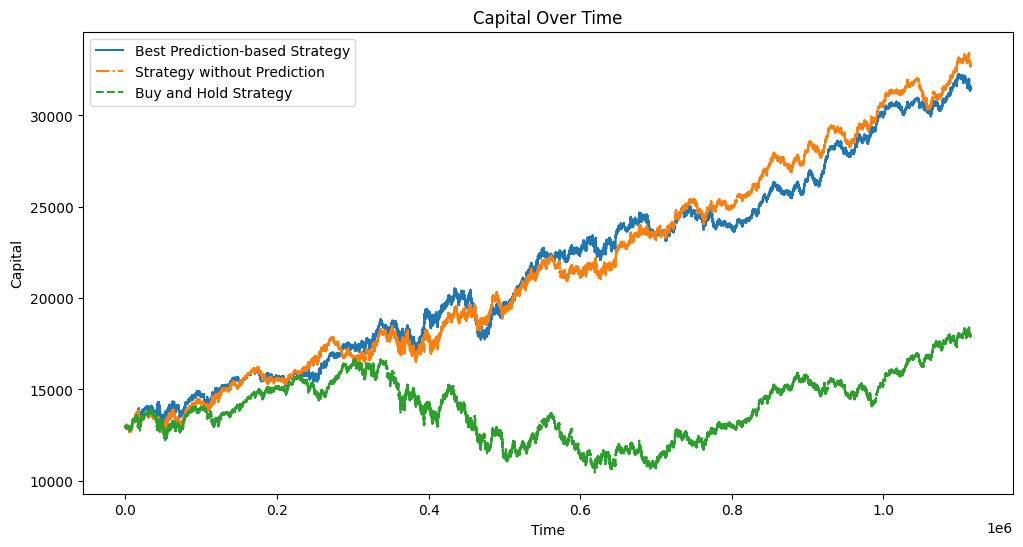

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(best_capital_over_time, label='Best Prediction-based Strategy')
plt.plot(capital_no_pred, label='Strategy without Prediction', linestyle='-.')
plt.plot(test_closes, label='Buy and Hold Strategy', linestyle='--')
plt.title('Capital Over Time')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.legend()
plt.show()

autoencoder: weights were loaded
Scaler loaded from scaler.pkl
34854/34854 ━━━━━━━━━━━━━━━━━━━━ 9s 248us/step
(True, True, True, True, True, True) 0.002553940638991163
(True, True, True, True, True, False) 0.0027950859640522878
(True, True, True, False, True, True) 0.0028867391597053142
(True, True, False, True, True, True) 0.003150325492933568
(True, True, False, True, True, False) 0.0031930711379131284
(True, False, False, True, True, False) 0.0032281098320451874
Best Configuration: (True, False, False, True, True, False)
Best Sharpe Ratio: 0.32


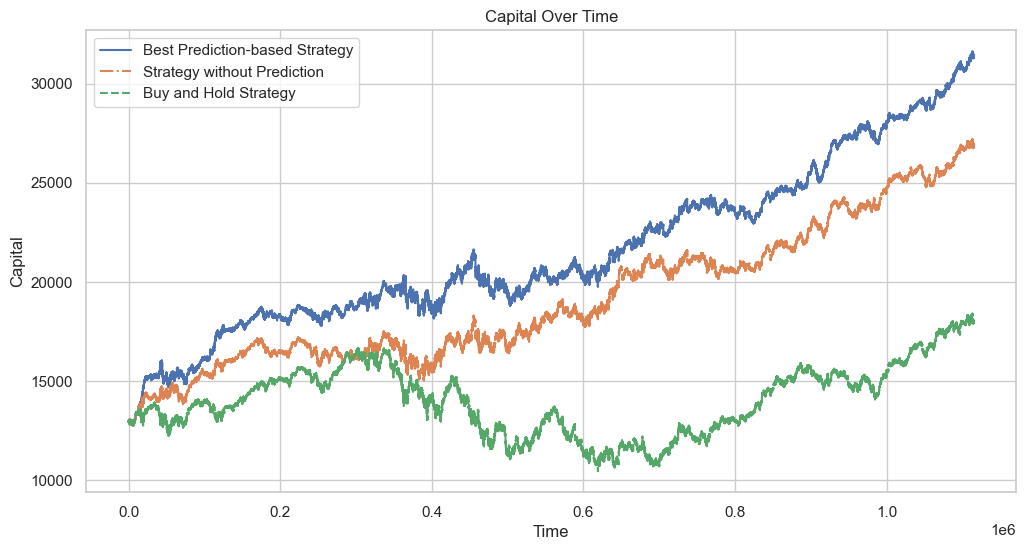

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import itertools

def simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config, use_prediction=True):
    initial_price = X_test[0]
    capital = initial_price
    capital_over_time = [initial_price]
    
    buy_and_hold_value = initial_price
    buy_and_hold_over_time = [initial_price]

    in_trade = False
    trade_type = None  # 1 for long, 0 for short

    long_trigger_value = 43
    short_trigger_value = -60
    stop_value = -160
    gain_value = 60

    sum_bull = 0
    sum_bear = 0
    accumulative_sum_pos = 0
    accumulative_sum_neg = 0
    prev_pos = 0
    prev_neg = 0

    short_stop = False
    long_stop = False

    prev_price = 0

    for i in range(1, len(X_test)):
        current_price = X_test[i]
        prev_price = X_test[i - 1]
        price_change = current_price - prev_price

        buy_and_hold_value += price_change
        buy_and_hold_over_time.append(buy_and_hold_value)

        prev_neg = accumulative_sum_neg
        prev_pos = accumulative_sum_pos

        if price_change > 0:
            accumulative_sum_pos += price_change
            accumulative_sum_neg = 0
        elif price_change < 0:
            accumulative_sum_neg += price_change
            accumulative_sum_pos = 0

        sum_bull = prev_pos if (prev_pos > 0 and accumulative_sum_pos == 0) else 0
        sum_bear = prev_neg if (prev_neg < 0 and accumulative_sum_neg == 0) else 0

        if use_prediction:
            cluster = pred[(i-1)]
            up = stop_loss_config[cluster]
        
            down = not up
        
            if up and trade_type == 0:  # Short trade and market is rising
                short_stop = True
            else:
                short_stop = False
                
            if down and trade_type == 1:  # Long trade and market is falling
                long_stop = True
            else:
                long_stop = False
           
        if sum_bull > long_trigger_value:
            if in_trade and trade_type == 0:
                ret = trade_entry_price - current_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price + stop_value
                highest_since_entry = current_price
                trade_type = 1
                in_trade = True

        elif sum_bear < short_trigger_value:
            if in_trade and trade_type == 1:
                ret = current_price - trade_entry_price
                capital += ret
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price - stop_value
                lowest_since_entry = current_price
                trade_type = 0
                in_trade = True

        if in_trade:
            if trade_type == 1:  # Long position
                if current_price - trade_entry_price >= gain_value:
                    stop_loss_price = max(stop_loss_price, current_price + stop_value)
                highest_since_entry = max(highest_since_entry, current_price)
                if long_stop and current_price <= stop_loss_price:
                    ret = current_price - trade_entry_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price - stop_value
                        lowest_since_entry = current_price
                        trade_type = 0
                        in_trade = True

            elif trade_type == 0:  # Short position
                if trade_entry_price - current_price >= gain_value:
                    stop_loss_price = min(stop_loss_price, current_price - stop_value)
                lowest_since_entry = min(lowest_since_entry, current_price)
                if short_stop and current_price >= stop_loss_price:
                    ret = trade_entry_price - current_price
                    capital += ret
                    in_trade = False
                    if not in_trade:
                        capital -= tc
                        trade_entry_price = current_price
                        stop_loss_price = trade_entry_price + stop_value
                        highest_since_entry = current_price
                        trade_type = 1
                        in_trade = True

        trade_value = capital
        if in_trade:
            trade_value += current_price - trade_entry_price if trade_type == 1 else trade_entry_price - current_price

        capital_over_time.append(trade_value)

        if not in_trade:
            highest_since_entry = 0
            lowest_since_entry = 0

    return capital_over_time, buy_and_hold_over_time

def optimize_strategy(X_test, pred, tc, stop_loss_pct):
    best_sharpe_ratio = -np.inf
    best_config = None
    best_capital_over_time = None

    # Generate all possible permutations in lexicographic order
    num_clusters = len(np.unique(pred))
    all_permutations = list(itertools.product([True, False], repeat=num_clusters))
    
    for stop_loss_config in all_permutations:
        capital_pred, _ = simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config)
        
        # Calculate daily returns
        daily_returns = np.diff(capital_pred) / capital_pred[:-1]
        
        # Calculate Sharpe Ratio (Assume risk-free rate = 0)
        mean_return = np.mean(daily_returns)
        std_return = np.std(daily_returns)
        sharpe_ratio = mean_return / std_return if std_return != 0 else 0

        if sharpe_ratio > best_sharpe_ratio:
            best_sharpe_ratio = sharpe_ratio
            best_config = stop_loss_config
            best_capital_over_time = capital_pred
            print(best_config, best_sharpe_ratio)

    
    return best_config, best_sharpe_ratio, best_capital_over_time

# Example usage
j = 0
test_closes = np.array(ohlc_data_ori['close'][j:])
initial_capital = test_closes[0]
tc = 1.5
stop_loss_pct = 0.10 

autoencoder = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')
scaler = load_scaler()
model_data_scaled = scaler.transform(model_data)
bottleneck_layer_index = len(autoencoder.layers) // 2
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[bottleneck_layer_index].output)
latent_representations = encoder.predict(model_data_scaled)
pred = gmm_model.predict(latent_representations).astype(np.int32)

best_config, best_sharpe_ratio, best_capital_over_time = optimize_strategy(test_closes, pred, tc, stop_loss_pct)

print(f"Best Configuration: {best_config}")
print(f"Best Sharpe Ratio: {best_sharpe_ratio*100:.2f}")

# Plot the results
capital_no_pred, _ = simulate_trading_strategy(test_closes, pred, tc, stop_loss_pct, stop_loss_config=best_config, use_prediction=False)

plt.figure(figsize=(12, 6))
plt.plot(best_capital_over_time, label='Best Prediction-based Strategy')
plt.plot(capital_no_pred, label='Strategy without Prediction', linestyle='-.')
plt.plot(test_closes, label='Buy and Hold Strategy', linestyle='--')
plt.title('Capital Over Time')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.legend()
plt.show()


autoencoder: weights were loaded
Scaler loaded from scaler.pkl
34854/34854 ━━━━━━━━━━━━━━━━━━━━ 8s 241us/step
(True, True, True, True, True, True) 0.00029323478539189927
(True, True, True, True, True, False) 0.00027690643492505327
(True, True, True, True, False, False) 0.0002750306215419907
(True, True, True, False, True, True) 0.0002729520438137817
(True, True, True, False, False, False) 0.00027228399556663625
(True, True, False, True, True, True) 0.0002691679466782737
(True, True, False, True, True, False) 0.00026869721069622986
(True, True, False, True, False, False) 0.0002685695688834953
(True, True, False, False, True, True) 0.00026837946846761226
(True, True, False, False, False, False) 0.0002681021060924508
(False, True, True, False, True, True) 0.0002673389094414456
(False, True, True, False, True, False) 0.0002671095285260755
(False, True, True, False, False, False) 0.00026635061431256647
(False, True, False, False, False, True) 0.00026625823016351527
(False, True, False, Fals

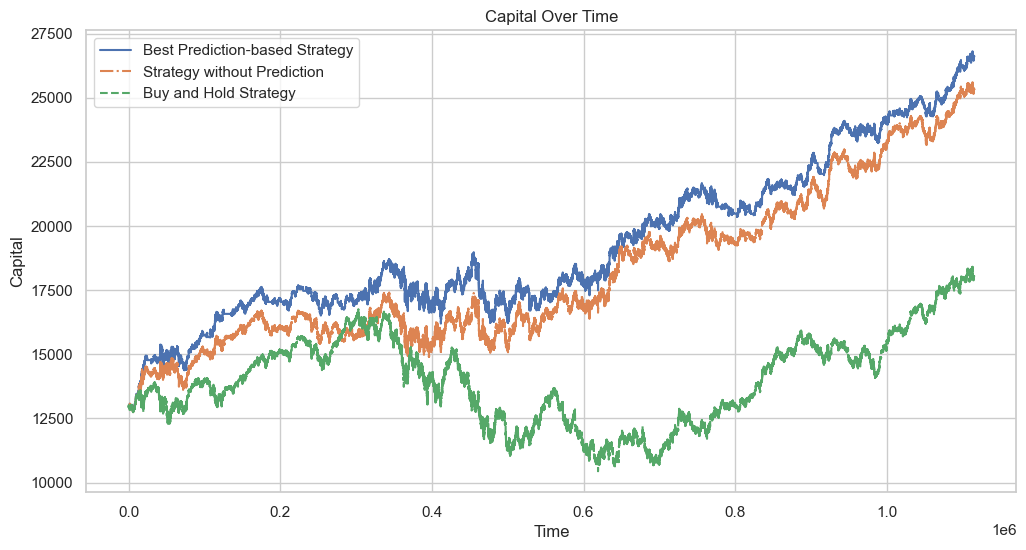

In [161]:
import numpy as np
import itertools

def calculate_volatility(capital_over_time):
    daily_returns = np.diff(capital_over_time) / capital_over_time[:-1]
    volatility = np.std(daily_returns)
    return volatility

def simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config, use_prediction=True):
    initial_price = X_test[0]
    capital = initial_price
    capital_over_time = [initial_price]
    
    buy_and_hold_value = initial_price
    buy_and_hold_over_time = np.zeros_like(X_test)
    buy_and_hold_over_time[0] = initial_price

    in_trade = False
    trade_type = None  # 1 for long, 0 for short

    long_trigger_value = 43
    short_trigger_value = -60
    stop_value = -160
    gain_value = 60

    accumulative_sum_pos = 0
    accumulative_sum_neg = 0

    short_stop = False
    long_stop = False

    for i in range(1, len(X_test)):
        current_price = X_test[i]
        prev_price = X_test[i - 1]
        price_change = current_price - prev_price

        buy_and_hold_value += price_change
        buy_and_hold_over_time[i] = buy_and_hold_value

        if price_change > 0:
            accumulative_sum_pos += price_change
            accumulative_sum_neg = 0
        elif price_change < 0:
            accumulative_sum_neg += price_change
            accumulative_sum_pos = 0

        sum_bull = accumulative_sum_pos
        sum_bear = accumulative_sum_neg

        if use_prediction:
            cluster = pred[i - 1]
            up = stop_loss_config[cluster]
            down = not up

            short_stop = (up and trade_type == 0)
            long_stop = (down and trade_type == 1)

        if sum_bull > long_trigger_value:
            if in_trade and trade_type == 0:
                capital += trade_entry_price - current_price
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price + stop_value
                highest_since_entry = current_price
                trade_type = 1
                in_trade = True

        elif sum_bear < short_trigger_value:
            if in_trade and trade_type == 1:
                capital += current_price - trade_entry_price
                in_trade = False
            if not in_trade:
                capital -= tc
                trade_entry_price = current_price
                stop_loss_price = trade_entry_price - stop_value
                lowest_since_entry = current_price
                trade_type = 0
                in_trade = True

        if in_trade:
            if trade_type == 1:  # Long position
                if current_price - trade_entry_price >= gain_value:
                    stop_loss_price = max(stop_loss_price, current_price + stop_value)
                highest_since_entry = max(highest_since_entry, current_price)
                if long_stop and current_price <= stop_loss_price:
                    capital += current_price - trade_entry_price
                    in_trade = False
            elif trade_type == 0:  # Short position
                if trade_entry_price - current_price >= gain_value:
                    stop_loss_price = min(stop_loss_price, current_price - stop_value)
                lowest_since_entry = min(lowest_since_entry, current_price)
                if short_stop and current_price >= stop_loss_price:
                    capital += trade_entry_price - current_price
                    in_trade = False

        trade_value = capital
        if in_trade:
            trade_value += (current_price - trade_entry_price) if trade_type == 1 else (trade_entry_price - current_price)

        capital_over_time.append(trade_value)

    return capital_over_time, buy_and_hold_over_time


def optimize_strategy(X_test, pred, tc, stop_loss_pct):
    best_volatility = np.inf
    best_config = None
    best_capital_over_time = None

    num_clusters = len(np.unique(pred))
    all_permutations = itertools.product([True, False], repeat=num_clusters)
    
    for stop_loss_config in all_permutations:
        capital_pred, _ = simulate_trading_strategy(X_test, pred, tc, stop_loss_pct, stop_loss_config)
        
        # Calculate Volatility
        volatility = calculate_volatility(capital_pred)
    
        if volatility < best_volatility:
            best_volatility = volatility
            best_config = stop_loss_config
            best_capital_over_time = capital_pred
            print(best_config, best_volatility)
    
    return best_config, best_volatility, best_capital_over_time


# Example usage
j = 0
test_closes = np.array(ohlc_data_ori['close'][j:])
initial_capital = test_closes[0]
tc = 1.5
stop_loss_pct = 0.10 

autoencoder = auto_encoder(load_weights=True, weights_file='weight_final_gmm15.weights.h5')
scaler = load_scaler()
model_data_scaled = scaler.transform(model_data)
bottleneck_layer_index = len(autoencoder.layers) // 2
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.layers[bottleneck_layer_index].output)
latent_representations = encoder.predict(model_data_scaled)
pred = gmm_model.predict(latent_representations).astype(np.int32)

best_config, best_volatility, best_capital_over_time = optimize_strategy(test_closes, pred, tc, stop_loss_pct)

print(f"Best Configuration: {best_config}")
print(f"Best Volatility: {best_volatility:.6f}")

# Plot the results
capital_no_pred, _ = simulate_trading_strategy(test_closes, pred, tc, stop_loss_pct, stop_loss_config=best_config, use_prediction=False)

plt.figure(figsize=(12, 6))
plt.plot(best_capital_over_time, label='Best Prediction-based Strategy')
plt.plot(capital_no_pred, label='Strategy without Prediction', linestyle='-.')
plt.plot(test_closes, label='Buy and Hold Strategy', linestyle='--')
plt.title('Capital Over Time')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.legend()
plt.show()


## CUSUM experiments

In [49]:
data_ori.head()


,datetime,open,high,low,close
0,2021-01-10 17:10:00,12991.1,12992.9,12978.0,12979.6
1,2021-01-11 17:11:00,12979.7,12987.7,12979.5,12979.8
2,2021-01-11 17:12:00,12980.0,12985.5,12974.4,12978.1
3,2021-01-11 17:13:00,12978.1,12984.6,12975.2,12981.4
4,2021-01-11 17:14:00,12981.1,12981.9,12974.7,12977.9


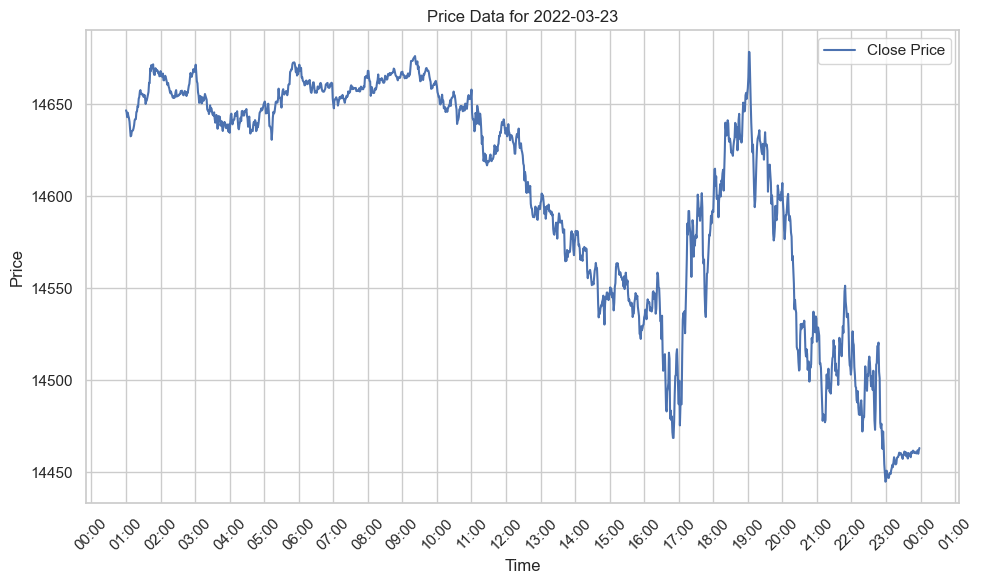

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assuming your DataFrame is named `data_ori`
# Convert 'datetime' column to pandas datetime if not already done
data_ori['datetime'] = pd.to_datetime(data_ori['datetime'])

# Extract a random day's worth of data
random_day = data_ori['datetime'].dt.date.sample(1).iloc[0]
day_data = data_ori[data_ori['datetime'].dt.date == random_day]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(day_data['datetime'], day_data['close'], label='Close Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title(f'Price Data for {random_day}')

# Set date format on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()


- Assume from above that market open frmo 15:00 to 00:00

### Steps to Estimate the Four Normal Distributions:

1. **Normalize the Price Changes**: Calculate the normalized price change for each observation as 

   \[
   \frac{x_{i+1} - x_i}{x_{i+1}}
   \]

   where \(x_i\) is the close price at time \(i\).

2. **Segment the Data into S and T Periods**: Based on the time of day, segment the data into two periods:
   - **S**: 15:00 to 00:00
   - **T**: The rest of the day.

3. **Separate Upwards and Downwards Movements**: For each period (S and T), separate the normalized price changes into those associated with upwards movements and those associated with downwards movements.

4. **Estimate Normal Distributions**: Fit a normal distribution to each of the four resulting datasets (upwards/downwards movements for S and T).


In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Load the data and calculate normalized price changes
data_ori['datetime'] = pd.to_datetime(data_ori['datetime'])
data_ori = data_ori.sort_values(by='datetime')
data_ori['price_change'] = (data_ori['close'].shift(-1) - data_ori['close']) / data_ori['close'].shift(-1)

# Step 2: Take the first 15% of rows
first_15_percent = int(len(data_ori) * 0.50)
data_sample = data_ori.iloc[:first_15_percent]

# Step 3: Define S and T periods
def classify_period(row):
    time = row['datetime'].time()
    if time >= pd.to_datetime("15:00").time() or time < pd.to_datetime("00:00").time():
        return 'S'
    else:
        return 'T'

data_sample['period'] = data_sample.apply(classify_period, axis=1)

# Step 4: Separate upwards and downwards movements for each period
upwards_S = data_sample[(data_sample['period'] == 'S') & (data_sample['price_change'] > 0)]['price_change'].dropna()
downwards_S = data_sample[(data_sample['period'] == 'S') & (data_sample['price_change'] <= 0)]['price_change'].dropna()
upwards_T = data_sample[(data_sample['period'] == 'T') & (data_sample['price_change'] > 0)]['price_change'].dropna()
downwards_T = data_sample[(data_sample['period'] == 'T') & (data_sample['price_change'] <= 0)]['price_change'].dropna()

# Step 5: Fit normal distributions
mu_up_S, std_up_S = norm.fit(upwards_S)
mu_down_S, std_down_S = norm.fit(downwards_S)
mu_up_T, std_up_T = norm.fit(upwards_T)
mu_down_T, std_down_T = norm.fit(downwards_T)

# Display the results
print(f'Normal Distribution for Upwards Movement in S Period: mean = {mu_up_S}, std = {std_up_S}')
print(f'Normal Distribution for Downwards Movement in S Period: mean = {mu_down_S}, std = {std_down_S}')
print(f'Normal Distribution for Upwards Movement in T Period: mean = {mu_up_T}, std = {std_up_T}')
print(f'Normal Distribution for Downwards Movement in T Period: mean = {mu_down_T}, std = {std_down_T}')


Normal Distribution for Upwards Movement in S Period: mean = 0.00036088622535904136, std = 0.00044725843733754196
Normal Distribution for Downwards Movement in S Period: mean = -0.00035658802180403196, std = 0.000462042178848687
Normal Distribution for Upwards Movement in T Period: mean = 0.00017041700099739788, std = 0.00020045356326322516
Normal Distribution for Downwards Movement in T Period: mean = -0.00016269065955572194, std = 0.0002038305437805316


/var/folders/mx/w2wt265x26n5z_26swrbljww0000gn/T/ipykernel_19466/3220266433.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



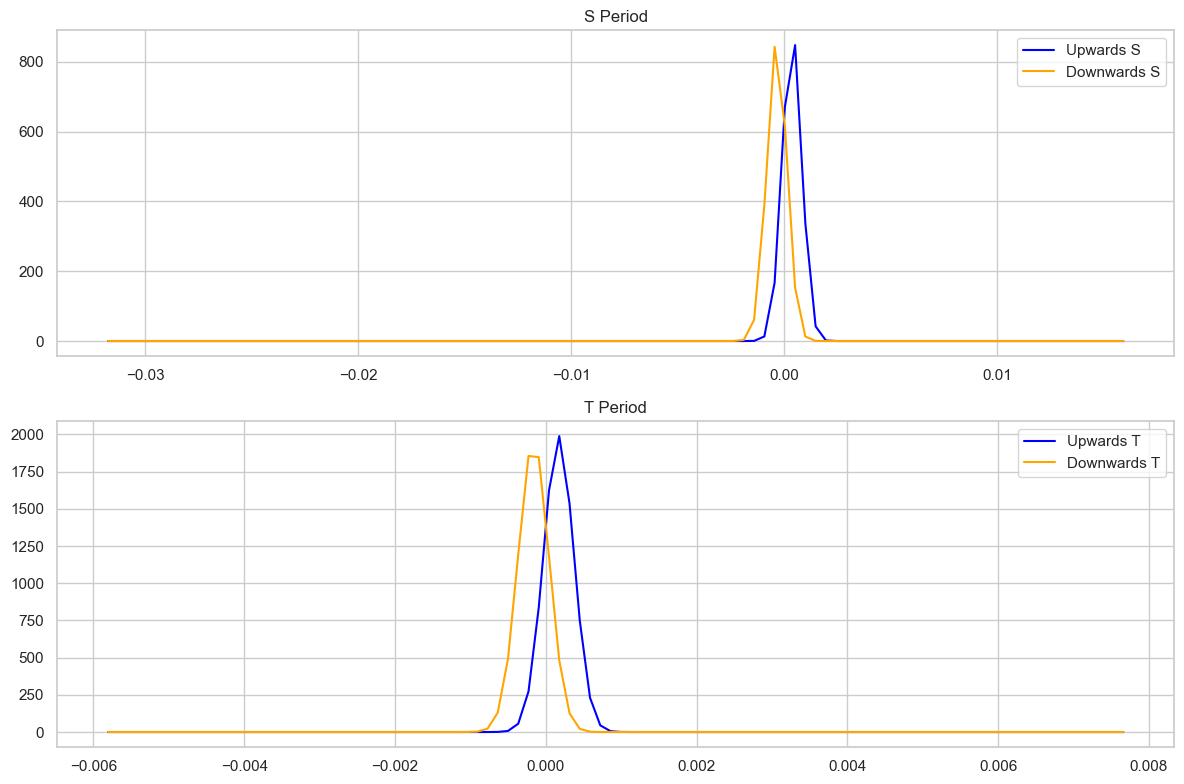

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Set a Seaborn style
sns.set(style="whitegrid")

# Create the figure with subplots
plt.figure(figsize=(12, 8))

# Plot for S period
plt.subplot(2, 1, 1)
x_range_S = np.linspace(min(upwards_S.min(), downwards_S.min()), max(upwards_S.max(), downwards_S.max()), 100)
sns.lineplot(x=x_range_S, 
             y=norm.pdf(x_range_S, mu_up_S, std_up_S), 
             label='Upwards S', color='blue')
sns.lineplot(x=x_range_S, 
             y=norm.pdf(x_range_S, mu_down_S, std_down_S), 
             label='Downwards S', color='orange')
plt.title('S Period')
plt.legend()

# Plot for T period
plt.subplot(2, 1, 2)
x_range_T = np.linspace(min(upwards_T.min(), downwards_T.min()), max(upwards_T.max(), downwards_T.max()), 100)
sns.lineplot(x=x_range_T, 
             y=norm.pdf(x_range_T, mu_up_T, std_up_T), 
             label='Upwards T', color='blue')
sns.lineplot(x=x_range_T, 
             y=norm.pdf(x_range_T, mu_down_T, std_down_T), 
             label='Downwards T', color='orange')
plt.title('T Period')
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


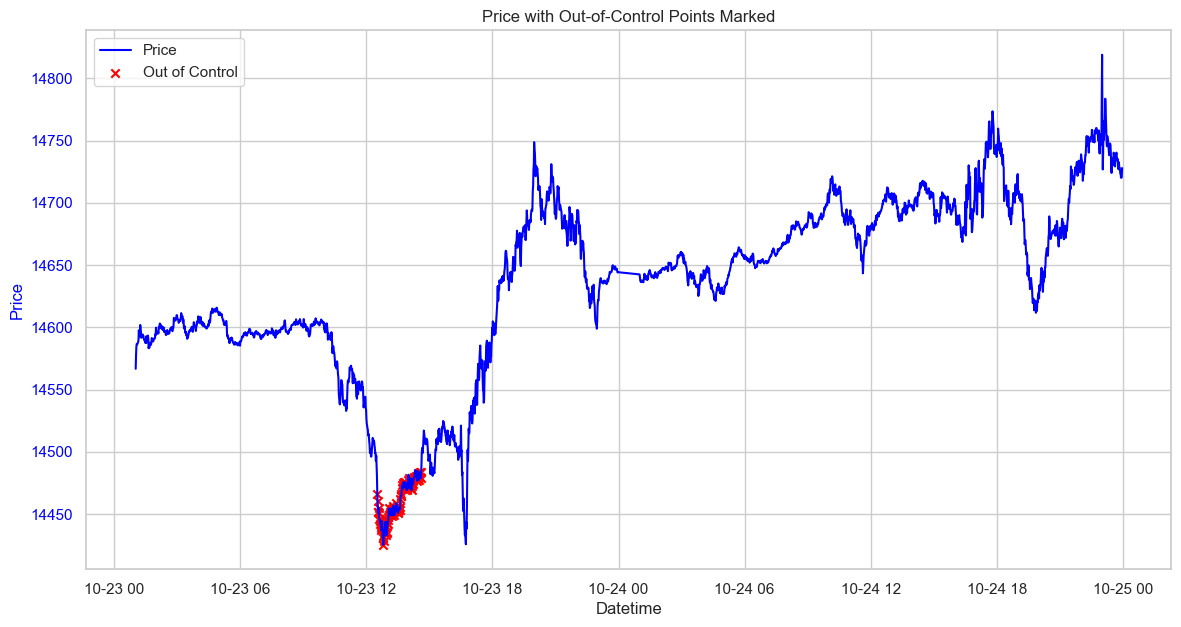

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assume these are already defined somewhere above
running_sum = 0
curr_period = "T"

def log_likelihood_ratio(change, mu1, std1, mu2, std2):
    prob1 = norm.pdf(change, mu1, std1)
    prob2 = norm.pdf(change, mu2, std2)
    return np.log(prob1 / prob2)

def calculate_cusum(obs, period, mu_down_S, std_down_S, mu_up_S, std_up_S, mu_down_T, std_down_T, mu_up_T, std_up_T, dell):
    global running_sum, curr_period
    
    if curr_period != period:
        running_sum = 0
        curr_period = period
    
    if period == 'S':
        s = log_likelihood_ratio(obs, mu_down_S, std_down_S, mu_down_S, std_down_S)
    else: 
        s = log_likelihood_ratio(obs, mu_down_T, std_down_T, mu_up_T, std_up_T)
    
    running_sum = np.max([0, running_sum + s])
    
    if running_sum > dell:
        return "Out of control", running_sum
    else:
        return "In control", running_sum


# Define the threshold for detecting an out-of-control process
dell = 100

results = []

# Create a copy of the datetime index to ensure no changes to the original data
data_copy = data_ori.copy()

# Extract unique dates from the datetime index without altering the original DataFrame
unique_dates = data_copy['datetime'].dt.date.unique()

# Randomly select a start day for the two-day period
start_index = np.random.randint(0, len(unique_dates) - 1)  # Ensure there's a next day
start_date = unique_dates[start_index]
end_date = unique_dates[start_index + 1]

# Extract data for the selected two contiguous days
two_day_data = data_copy[(data_copy['datetime'].dt.date == start_date) | (data_copy['datetime'].dt.date == end_date)].copy()

# Loop through the two-day data to calculate standardized changes and update CUSUM
for i in range(1, len(two_day_data)):
    obs = two_day_data.iloc[i]['close']
    prev_obs = two_day_data.iloc[i - 1]['close']
    std_change = (obs - prev_obs) / obs
    
    period = 'S' if two_day_data.iloc[i]['datetime'].time() >= pd.to_datetime("15:00").time() or two_day_data.iloc[i]['datetime'].time() < pd.to_datetime("00:00").time() else 'T'
    
    result, current_sum = calculate_cusum(
        obs=std_change,  # Using standardized change
        period=period, 
        mu_down_S=mu_down_S, std_down_S=std_down_S, 
        mu_up_S=mu_up_S, std_up_S=std_up_S,
        mu_down_T=mu_down_T, std_down_T=std_down_T, 
        mu_up_T=mu_up_T, std_up_T=std_up_T,
        dell=dell
    )
    
    results.append({
        'datetime': two_day_data.iloc[i]['datetime'],
        'period': period,
        'price_change': std_change,
        'close_price': obs,
        'status': result
    })

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Plotting the Price and marking Out-of-Control points
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the price on the y-axis
ax1.plot(results_df['datetime'], results_df['close_price'], color='blue', label='Price')
ax1.set_xlabel('Datetime')
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Mark the out-of-control points with red 'x'
out_of_control_df = results_df[results_df['status'] == 'Out of control']
ax1.scatter(out_of_control_df['datetime'], out_of_control_df['close_price'], color='red', label='Out of Control', marker='x')

# Adding title and showing the plot
plt.title('Price with Out-of-Control Points Marked')
plt.legend()
plt.show()


## VAE

### data before feature extract ###
             datetime     open     high      low    close
0 2021-01-10 17:10:00  12991.1  12992.9  12978.0  12979.6
1 2021-01-11 17:11:00  12979.7  12987.7  12979.5  12979.8
2 2021-01-11 17:12:00  12980.0  12985.5  12974.4  12978.1
3 2021-01-11 17:13:00  12978.1  12984.6  12975.2  12981.4
4 2021-01-11 17:14:00  12981.1  12981.9  12974.7  12977.9
### data after feature extract ###
    EMA_medium  SMA_medium  MACD_medium  RSI_medium  Momentum_medium  \
48   -0.000580   -0.000058    -1.000129   -0.995826        -1.000600   
49   -0.000132    0.000346    -1.000104   -0.995996        -1.001047   
50    0.000013    0.000448    -1.000092   -0.996051        -1.001309   
51    0.000351    0.000744    -1.000103   -0.996186        -1.001995   
52    0.000299    0.000647    -1.000110   -0.996174        -1.001988   

    PROC_medium  Stochastic_K_medium  CCI_medium  ATR_medium  \
48         -1.0            -0.997847   -1.000614   -0.999234   
49         -1.0     

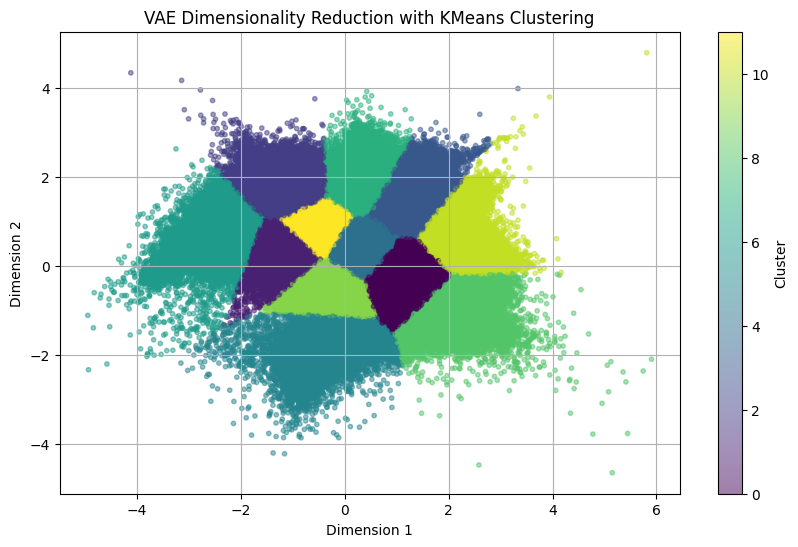

In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

# Define the VAE loss function
def vae_loss(x, x_recon, z_mu, z_logvar, beta=1.0, capacity=0.0):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + z_logvar - z_mu.pow(2) - z_logvar.exp())
    return recon_loss + beta * kl_loss

# Define the VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dims):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dims[2], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[2], latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Load and preprocess the data
model_df = create_model_df(data.copy())
train, test, scaler = split_scale_data(model_df, 0.7)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)

# Convert the data to PyTorch tensors
train_tensor = torch.tensor(train_scaled, dtype=torch.float32)

# Define VAE parameters
input_dim = train_tensor.shape[1]
latent_dim = 2
hidden_dims = [64, 32, 16]
lr = 1e-3
batch_size = 32
epochs = 5

# Create DataLoader
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize the VAE model
vae = VAE(input_dim, latent_dim, hidden_dims)
optimizer = optim.Adam(vae.parameters(), lr=lr)

# Train the VAE
vae.train()
for epoch in range(epochs):
    train_loss = 0
    for x_batch in train_loader:
        x = x_batch[0]
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(x)
        loss = vae_loss(x, x_recon, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f"Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}")

# Use the encoder to reduce the dimensionality
vae.eval()
with torch.no_grad():
    z_mean, _ = vae.encode(train_tensor)
    z_mean = z_mean.numpy()

# Standardize the latent encodings
latent_scaler = StandardScaler()
subset_df_encoded_scaled = latent_scaler.fit_transform(z_mean)

# Fit KMeans clustering on the standardized latent encodings
kmeans = KMeans(n_clusters=12, random_state=42)
clusters = kmeans.fit_predict(subset_df_encoded_scaled)

# Evaluate clustering using Davies-Bouldin Index
db_index = davies_bouldin_score(subset_df_encoded_scaled, clusters)
print(f'Davies-Bouldin Index: {db_index}')

# Plot the VAE results with KMeans clustering
plt.figure(figsize=(10, 6))
plt.scatter(subset_df_encoded_scaled[:, 0], subset_df_encoded_scaled[:, 1], c=clusters, cmap='viridis', s=10, alpha=0.5)
plt.title('VAE Dimensionality Reduction with KMeans Clustering')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

In [106]:
# Use the encoder to reduce the dimensionality
z_mean, _, _ = encoder.predict(subset_df_scaled)

# Standardize the latent encodings
latent_scaler = StandardScaler()
subset_df_encoded_scaled = latent_scaler.fit_transform(z_mean)

# Fit KMeans clustering on the standardized latent encodings
kmeans = KMeans(n_clusters=12, random_state=42)  # Adjust the number of clusters as needed
clusters = kmeans.fit_predict(subset_df_encoded_scaled)

# Evaluate clustering using Davies-Bouldin Index
db_index = davies_bouldin_score(subset_df_encoded_scaled, clusters)
print(f'Davies-Bouldin Index: {db_index}')

# Plot the VAE results with KMeans clustering
plt.figure(figsize=(10, 6))
plt.scatter(subset_df_encoded_scaled[:, 0], subset_df_encoded_scaled[:, 1], c=clusters, cmap='viridis', s=10, alpha=0.5)
plt.title('VAE Dimensionality Reduction with KMeans Clustering')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

### data before feature extract ###
             datetime     open     high      low    close
0 2022-12-06 17:24:00  11631.3  11636.9  11628.4  11635.0
1 2022-12-06 17:25:00  11635.0  11639.7  11633.2  11634.2
2 2022-12-06 17:26:00  11634.3  11640.4  11630.3  11640.4
3 2022-12-06 17:27:00  11640.3  11640.4  11627.5  11628.1
4 2022-12-06 17:28:00  11628.2  11629.5  11620.9  11621.1
### data after feature extract ###
    EMA_medium  SMA_medium  MACD_medium  RSI_medium  Momentum_medium  \
48    0.000014    0.000063    -1.000196   -0.996033        -0.998415   
49    0.000658    0.000761    -1.000214   -0.996208        -0.999733   
50    0.000358    0.000448    -1.000210   -0.996121        -1.001129   
51    0.001902    0.002008    -1.000307   -0.996513        -1.003454   
52    0.001747    0.001875    -1.000382   -0.996502        -1.002953   

    PROC_medium  Stochastic_K_medium  CCI_medium  ATR_medium  \
48         -1.0            -0.995698   -0.997598   -0.999034   
49         -1.0     

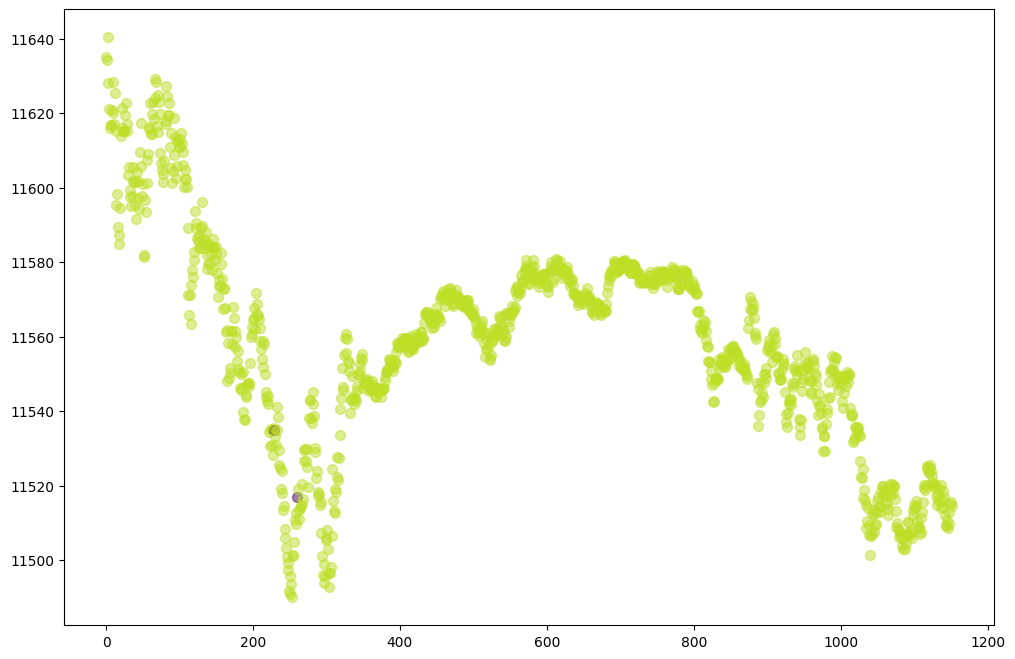

In [119]:
# Sample a contiguous segment of 500 candles for plotting
candles_subset = sample_contiguous_segment(data, 1200)
candles_subset.reset_index(inplace=True, drop=True)

# Extract features for the subset and scale them
candles_features_subset = create_model_df(candles_subset)
candles_features_subset_scaled = scaler.transform(candles_features_subset)

# Convert to PyTorch tensor
candles_features_subset_tensor = torch.tensor(candles_features_subset_scaled, dtype=torch.float32)

# Get the corresponding latent encodings for the subset
vae.eval()
with torch.no_grad():
    candles_subset_encoded, _ = vae.encode(candles_features_subset_tensor)
    candles_subset_encoded = candles_subset_encoded.numpy()

# Standardize the latent encodings
candles_subset_encoded_scaled = latent_scaler.transform(candles_subset_encoded)

# Fit KMeans clustering on the standardized latent encodings
candles_clusters = kmeans.predict(candles_subset_encoded_scaled)

# Plot the candlesticks with their associated clusterings
fig, ax = plt.subplots(figsize=(12, 8))

# Function to plot candlesticks
def plot_candlesticks(data, ax, clusters):
    for i in range(len(data)):
        # Plot the cluster as a dot
        ax.scatter(i, data['close'][i], color=plt.cm.viridis(clusters[i] / (max(clusters) + 1)), s=50, alpha=0.5)

plot_candlesticks(candles_subset, ax, candles_clusters)

ax.set_title('Candlestick Chart with Cluster Annotations')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
plt.colorbar(ax.scatter(range(len(candles_clusters)), candles_subset['close'], c=candles_clusters, cmap='viridis', s=50, alpha=0.5), label='Cluster')
plt.grid(True)
plt.show()